# EEG Deep Dive: Ambiguity-Specific Neural Signatures

**Purpose**: Investigate whether EEG features, particularly frontal theta, show stronger effects under high ambiguity conditions where behavioral cues are less informative.

**Key Analyses**:
1. **Theta × Ambiguity × Choice interaction**: Does frontal theta differentiate choices more under high ambiguity?
2. **EEG-only accuracy by ambiguity level**: When does EEG contribute most?
3. **Band × Region × Ambiguity heatmaps**: Where are the strongest neural signatures?
4. **Fronto-parietal coherence**: Network-level decision signals

**Neuroscience Background**:
- Frontal theta (4-8 Hz) is the canonical marker of cognitive conflict and uncertainty (Cavanagh & Frank, 2014)
- Beta suppression reflects motor preparation
- Fronto-parietal communication supports evidence integration

In [1]:
import sys
sys.path.append('../..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats, signal
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.metrics import accuracy_score, f1_score
from sklearn.impute import SimpleImputer
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

from src.features.eeg_features import (
    FREQ_BANDS, CHANNEL_REGIONS, CHANNEL_NAMES,
    compute_band_power, compute_psd
)

np.random.seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Paths
OUTPUT_DIR = Path('../../data/results/main/eeg_integration/eeg_deep_dive')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"{'='*70}")
print(f"EEG DEEP DIVE: AMBIGUITY-SPECIFIC NEURAL SIGNATURES")
print(f"{'='*70}")
print(f"Analysis started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

EEG DEEP DIVE: AMBIGUITY-SPECIFIC NEURAL SIGNATURES
Analysis started: 2026-04-21 11:26:11


## 1. Load Data

In [2]:
# Load behavioral/physio features
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)

merged_df = feature_data['merged_df']
physio_cols = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols = feature_data['gaze_cols']

print(f"Loaded {len(merged_df)} trials from {merged_df['subject_id'].nunique()} subjects")

# Load EEG features (regional_bands for interpretability)
with open('../../data/features/eeg_features_regional_bands.pkl', 'rb') as f:
    eeg_data = pickle.load(f)

eeg_features_df = eeg_data['eeg_features_df']
eeg_cols = eeg_data['feature_columns']

print(f"Loaded {len(eeg_features_df)} EEG trials from {eeg_features_df['subject_id'].nunique()} subjects")
print(f"EEG features: {eeg_cols}")

# Merge
merged_with_eeg = merged_df.merge(
    eeg_features_df[['trial_id'] + eeg_cols],
    on='trial_id',
    how='inner'
)

# Create ambiguity groups
merged_with_eeg['ambiguity_group'] = merged_with_eeg['ambiguity'].replace({0: 'Low', 3: 'Medium', 6: 'High'})

print(f"\nMerged dataset: {len(merged_with_eeg)} trials, {merged_with_eeg['subject_id'].nunique()} subjects")
print(f"\nAmbiguity distribution:")
print(merged_with_eeg['ambiguity_group'].value_counts())

Loaded 12107 trials from 102 subjects
Loaded 10212 EEG trials from 80 subjects
EEG features: ['eeg_Delta_Frontal', 'eeg_Delta_Central', 'eeg_Delta_Parietal', 'eeg_Delta_Occipital', 'eeg_Theta_Frontal', 'eeg_Theta_Central', 'eeg_Theta_Parietal', 'eeg_Theta_Occipital', 'eeg_Alpha_Frontal', 'eeg_Alpha_Central', 'eeg_Alpha_Parietal', 'eeg_Alpha_Occipital', 'eeg_Beta_Frontal', 'eeg_Beta_Central', 'eeg_Beta_Parietal', 'eeg_Beta_Occipital']

Merged dataset: 9365 trials, 80 subjects

Ambiguity distribution:
ambiguity_group
Low       3143
Medium    3121
High      3101
Name: count, dtype: int64


## 2. Analysis 1: Theta × Ambiguity × Choice Interaction

Test whether frontal theta differentiates INVEST vs KEEP choices more strongly under high ambiguity.

In [3]:
def compute_cohens_d(group1, group2):
    """Compute Cohen's d effect size."""
    n1, n2 = len(group1), len(group2)
    if n1 < 2 or n2 < 2:
        return 0
    var1, var2 = group1.var(), group2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    if pooled_std == 0:
        return 0
    return (group1.mean() - group2.mean()) / pooled_std

# Compute effect sizes for each EEG feature, split by ambiguity
results = []

for ambiguity in ['Low', 'Medium', 'High']:
    amb_df = merged_with_eeg[merged_with_eeg['ambiguity_group'] == ambiguity]
    invest_df = amb_df[amb_df['outcome'] == 1]
    keep_df = amb_df[amb_df['outcome'] == 0]
    
    for col in eeg_cols:
        invest_vals = invest_df[col].dropna()
        keep_vals = keep_df[col].dropna()
        
        if len(invest_vals) < 10 or len(keep_vals) < 10:
            continue
        
        t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
        d = compute_cohens_d(invest_vals, keep_vals)
        
        # Parse feature name
        parts = col.split('_')
        band = parts[1]
        region = parts[2]
        
        results.append({
            'ambiguity': ambiguity,
            'feature': col,
            'band': band,
            'region': region,
            'cohens_d': d,
            'abs_d': abs(d),
            'p_value': p_val,
            'invest_mean': invest_vals.mean(),
            'keep_mean': keep_vals.mean(),
            'n_invest': len(invest_vals),
            'n_keep': len(keep_vals)
        })

effect_df = pd.DataFrame(results)
print(f"Computed {len(effect_df)} effect sizes ({len(eeg_cols)} features × 3 ambiguity levels)")

Computed 48 effect sizes (16 features × 3 ambiguity levels)


In [4]:
# Focus on FRONTAL THETA - the key hypothesis
print("\n" + "="*70)
print("FRONTAL THETA × AMBIGUITY × CHOICE")
print("="*70)
print("\nHypothesis: Frontal theta should differentiate choices MORE under high ambiguity")
print("(Higher theta = more conflict/uncertainty, expected for KEEP decisions)\n")

theta_frontal = effect_df[(effect_df['band'] == 'Theta') & (effect_df['region'] == 'Frontal')]
print(theta_frontal[['ambiguity', 'cohens_d', 'p_value', 'invest_mean', 'keep_mean']].to_string(index=False))

# Test for interaction: does effect size increase with ambiguity?
print("\n" + "-"*50)
print("Effect size trend across ambiguity levels:")
for amb in ['Low', 'Medium', 'High']:
    d = theta_frontal[theta_frontal['ambiguity'] == amb]['cohens_d'].values[0]
    print(f"  {amb}: d = {d:.4f}")


FRONTAL THETA × AMBIGUITY × CHOICE

Hypothesis: Frontal theta should differentiate choices MORE under high ambiguity
(Higher theta = more conflict/uncertainty, expected for KEEP decisions)

ambiguity  cohens_d  p_value  invest_mean  keep_mean
      Low -0.176887 0.002347     0.047436   0.065718
   Medium -0.105143 0.031994     0.047609   0.056076
     High -0.111702 0.020646     0.046730   0.056985

--------------------------------------------------
Effect size trend across ambiguity levels:
  Low: d = -0.1769
  Medium: d = -0.1051
  High: d = -0.1117


### 2.1 Subject-Level Consistency: Is KEEP > INVEST Theta Universal?

The group-level analysis shows KEEP trials have higher frontal theta than INVEST trials. But is this pattern:
- **Consistent across subjects?** (most subjects show KEEP > INVEST)
- **Or driven by outliers?** (a few subjects with extreme effects)


SUBJECT-LEVEL ANALYSIS: FRONTAL THETA BY CHOICE

Question: Is the KEEP > INVEST theta pattern consistent across subjects,
or driven by a few outliers?

Total subjects in merged_with_eeg: 80

Subjects analyzed: 69
Subjects excluded: 11

Excluded subjects (need ≥5 trials per choice):
  0823_1400_9M4VCHG: Too few trials (INVEST=21, KEEP=0)
  0826_1000_539136F: Too few trials (INVEST=28, KEEP=0)
  0901_1000_U9TEJGM: Too few trials (INVEST=30, KEEP=4)
  0917_1030_9M4VCHG: Too few trials (INVEST=8, KEEP=0)
  0923_1000_539136F: Too few trials (INVEST=13, KEEP=0)
  0923_1000_9M4VCHG: Too few trials (INVEST=53, KEEP=4)
  0924_1000_539136F: Too few trials (INVEST=16, KEEP=3)
  0924_1000_9M4VCHG: Too few trials (INVEST=25, KEEP=1)
  0924_1600_539136F: Too few trials (INVEST=5, KEEP=1)
  0930_1700_539136F: Too few trials (INVEST=14, KEEP=0)
  1005_1600_U9TEJGM: Too few trials (INVEST=8, KEEP=0)

--------------------------------------------------
Direction of effect:
  KEEP > INVEST (d < 0): 42 su

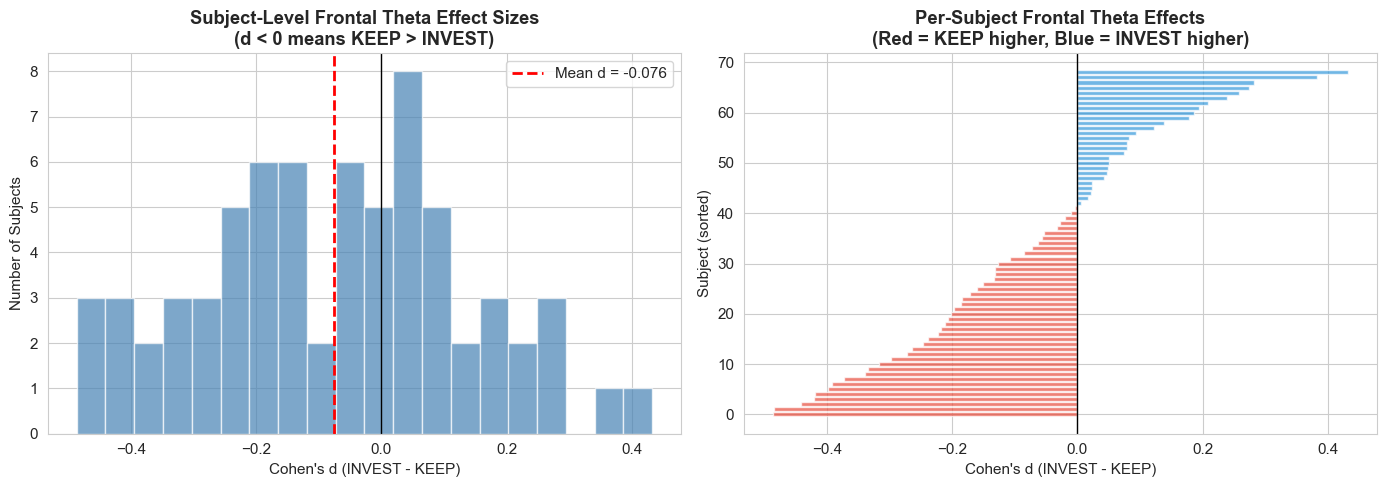


One-sample t-test (H0: mean d = 0):
  Mean d = -0.0764
  t = -2.968, p = 0.0041 *


In [5]:
# =============================================================================
# SUBJECT-LEVEL ANALYSIS: Is KEEP > INVEST theta consistent across subjects?
# =============================================================================
print("\n" + "="*70)
print("SUBJECT-LEVEL ANALYSIS: FRONTAL THETA BY CHOICE")
print("="*70)
print("\nQuestion: Is the KEEP > INVEST theta pattern consistent across subjects,")
print("or driven by a few outliers?\n")

# Debug: Check why some subjects might be excluded
print(f"Total subjects in merged_with_eeg: {merged_with_eeg['subject_id'].nunique()}")

# Compute per-subject effect sizes for frontal theta
subject_effects = []
excluded_subjects = []

for subject in merged_with_eeg['subject_id'].unique():
    subj_df = merged_with_eeg[merged_with_eeg['subject_id'] == subject]
    invest_vals = subj_df[subj_df['outcome'] == 1]['eeg_Theta_Frontal'].dropna()
    keep_vals = subj_df[subj_df['outcome'] == 0]['eeg_Theta_Frontal'].dropna()
    
    # Track why subjects are excluded
    if len(invest_vals) < 5 or len(keep_vals) < 5:
        excluded_subjects.append({
            'subject_id': subject,
            'n_invest': len(invest_vals),
            'n_keep': len(keep_vals),
            'reason': f"Too few trials (INVEST={len(invest_vals)}, KEEP={len(keep_vals)})"
        })
        continue
    
    d = compute_cohens_d(invest_vals, keep_vals)
    t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
    subject_effects.append({
        'subject_id': subject,
        'cohens_d': d,
        'p_value': p_val,
        'invest_mean': invest_vals.mean(),
        'keep_mean': keep_vals.mean(),
        'n_invest': len(invest_vals),
        'n_keep': len(keep_vals),
        'n_total': len(subj_df),
        'invest_rate': len(invest_vals) / len(subj_df),
        'direction': 'KEEP > INVEST' if d < 0 else 'INVEST > KEEP'
    })

subject_effects_df = pd.DataFrame(subject_effects)

# Report on excluded subjects
print(f"\nSubjects analyzed: {len(subject_effects_df)}")
print(f"Subjects excluded: {len(excluded_subjects)}")
if excluded_subjects:
    print("\nExcluded subjects (need ≥5 trials per choice):")
    excluded_df = pd.DataFrame(excluded_subjects)
    for _, row in excluded_df.iterrows():
        print(f"  {row['subject_id']}: {row['reason']}")

# Summary statistics
n_keep_higher = (subject_effects_df['cohens_d'] < 0).sum()
n_invest_higher = (subject_effects_df['cohens_d'] > 0).sum()
n_sig_keep = ((subject_effects_df['cohens_d'] < 0) & (subject_effects_df['p_value'] < 0.05)).sum()
n_sig_invest = ((subject_effects_df['cohens_d'] > 0) & (subject_effects_df['p_value'] < 0.05)).sum()

print(f"\n" + "-"*50)
print(f"Direction of effect:")
print(f"  KEEP > INVEST (d < 0): {n_keep_higher} subjects ({100*n_keep_higher/len(subject_effects_df):.1f}%)")
print(f"  INVEST > KEEP (d > 0): {n_invest_higher} subjects ({100*n_invest_higher/len(subject_effects_df):.1f}%)")
print(f"\nSignificant effects (p < 0.05):")
print(f"  KEEP > INVEST: {n_sig_keep} subjects")
print(f"  INVEST > KEEP: {n_sig_invest} subjects")

# Binomial test: is the proportion significantly different from 50%?
from scipy.stats import binomtest
binom_result = binomtest(n_keep_higher, len(subject_effects_df), p=0.5)
print(f"\nBinomial test (H0: 50% show KEEP > INVEST):")
print(f"  p = {binom_result.pvalue:.4f} {'*' if binom_result.pvalue < 0.05 else ''}")

# Visualize subject-level effects
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Histogram of subject-level Cohen's d
ax = axes[0]
ax.hist(subject_effects_df['cohens_d'], bins=20, color='steelblue', edgecolor='white', alpha=0.7)
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.axvline(subject_effects_df['cohens_d'].mean(), color='red', linestyle='--', linewidth=2, 
           label=f"Mean d = {subject_effects_df['cohens_d'].mean():.3f}")
ax.set_xlabel("Cohen's d (INVEST - KEEP)")
ax.set_ylabel("Number of Subjects")
ax.set_title("Subject-Level Frontal Theta Effect Sizes\n(d < 0 means KEEP > INVEST)", fontweight='bold')
ax.legend()

# Plot 2: Sorted effect sizes with error indication
ax = axes[1]
sorted_df = subject_effects_df.sort_values('cohens_d')
colors = ['#E74C3C' if d < 0 else '#3498DB' for d in sorted_df['cohens_d']]
ax.barh(range(len(sorted_df)), sorted_df['cohens_d'], color=colors, alpha=0.7)
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel("Cohen's d (INVEST - KEEP)")
ax.set_ylabel("Subject (sorted)")
ax.set_title("Per-Subject Frontal Theta Effects\n(Red = KEEP higher, Blue = INVEST higher)", fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'subject_level_theta_effects.png', dpi=300, bbox_inches='tight')
plt.show()

# One-sample t-test: is mean effect significantly different from 0?
t_stat, p_val = stats.ttest_1samp(subject_effects_df['cohens_d'], 0)
print(f"\nOne-sample t-test (H0: mean d = 0):")
print(f"  Mean d = {subject_effects_df['cohens_d'].mean():.4f}")
print(f"  t = {t_stat:.3f}, p = {p_val:.4f} {'*' if p_val < 0.05 else ''}")

### 2.1b What Distinguishes Subjects with Opposite Theta Patterns?

~50% of subjects show KEEP > INVEST theta, while ~50% show the reverse. What explains this individual difference?

**Hypotheses:**
1. **Risk preference**: Risk-averse subjects may show more conflict (theta) when choosing INVEST
2. **Decision strategy**: Some subjects may deliberate more on risky choices, others on safe choices
3. **Baseline theta**: High-theta subjects may show different patterns than low-theta subjects
4. **Task engagement**: More engaged subjects may show clearer differentiation


INDIVIDUAL DIFFERENCES: KEEP-THETA vs INVEST-THETA SUBJECTS

KEEP-Theta subjects (higher theta for KEEP): 42
INVEST-Theta subjects (higher theta for INVEST): 27

----------------------------------------------------------------------
GROUP COMPARISONS (KEEP-Theta vs INVEST-Theta)
----------------------------------------------------------------------

Overall INVEST Rate:
  KEEP-Theta:   0.6438 ± 0.1597
  INVEST-Theta: 0.5647 ± 0.1234
  t = 2.19, p = 0.0322 *, d = 0.539

Mean Decision Time (s):
  KEEP-Theta:   2.4071 ± 0.5105
  INVEST-Theta: 2.5685 ± 0.4526
  t = -1.34, p = 0.1852 , d = -0.330

EV-Choice Correlation:
  KEEP-Theta:   0.1453 ± 0.2983
  INVEST-Theta: 0.1273 ± 0.3044
  t = 0.24, p = 0.8084 , d = 0.060

Ambiguity Sensitivity:
  KEEP-Theta:   0.3571 ± 0.2701
  INVEST-Theta: 0.4270 ± 0.4143
  t = -0.85, p = 0.3985 , d = -0.210

Mean Frontal Theta:
  KEEP-Theta:   0.0436 ± 0.0727
  INVEST-Theta: 0.0626 ± 0.0623
  t = -1.12, p = 0.2650 , d = -0.277

Theta Variability:
  KEEP-The

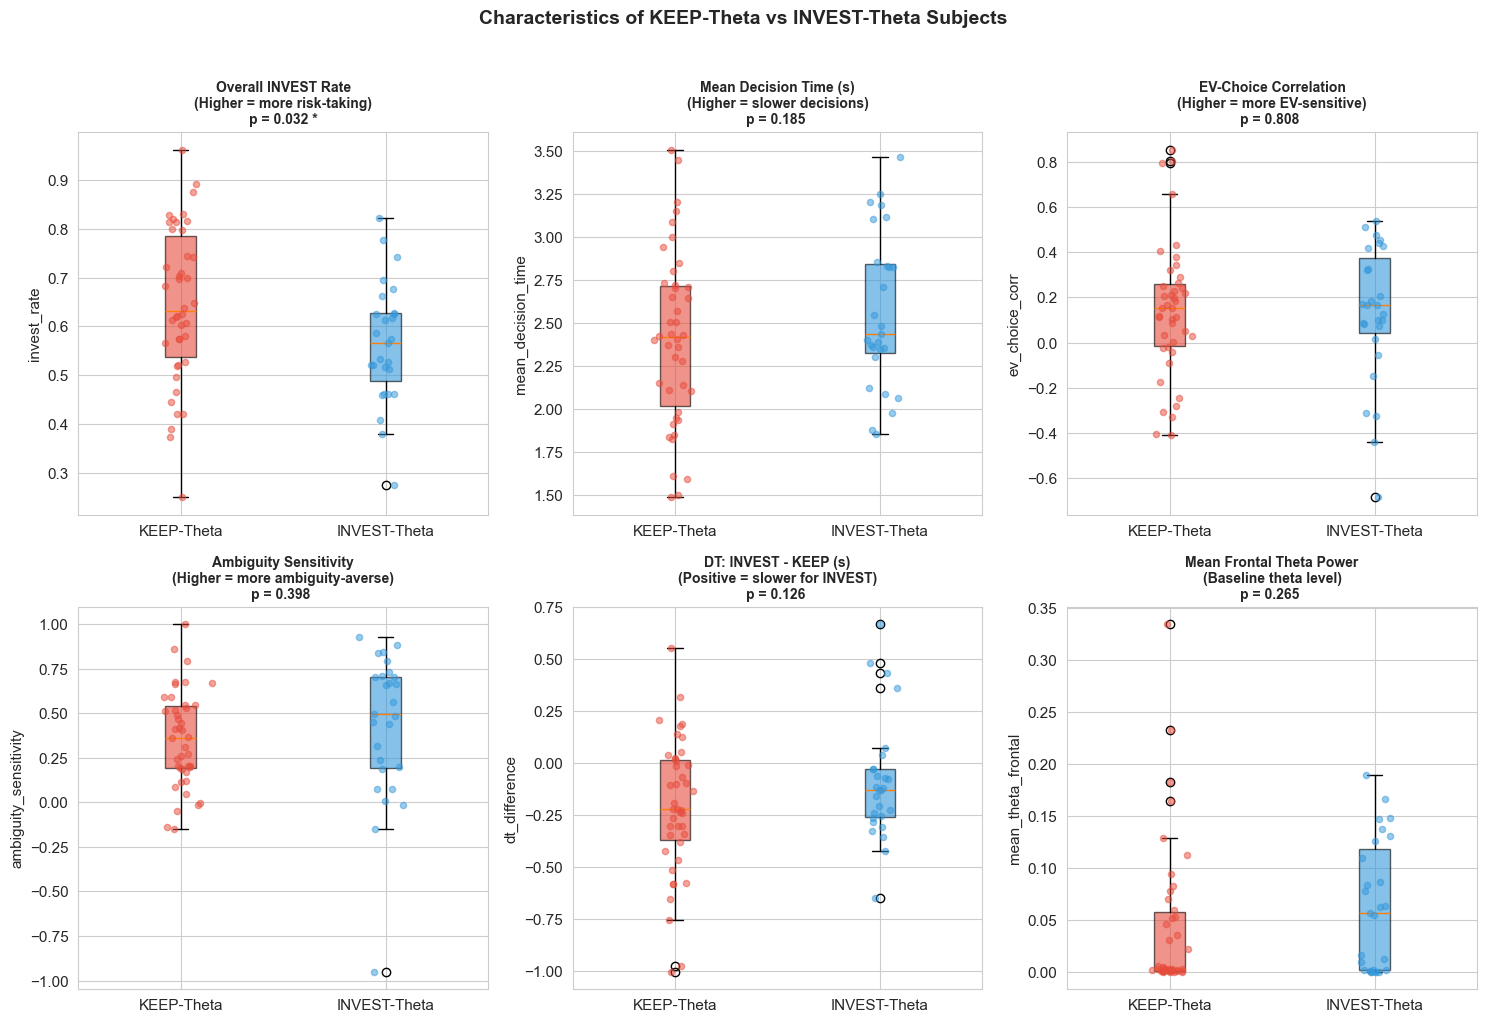


CORRELATIONS WITH THETA EFFECT SIZE

Does the magnitude/direction of theta effect correlate with behavior?
  invest_rate              : r = -0.247, p = 0.0409 *
  mean_decision_time       : r = +0.145, p = 0.2331 
  ev_choice_corr           : r = +0.015, p = 0.9057 
  ambiguity_sensitivity    : r = +0.152, p = 0.2126 
  dt_difference            : r = +0.128, p = 0.2939 
  mean_theta_frontal       : r = +0.172, p = 0.1575 


In [6]:
# =============================================================================
# WHAT DISTINGUISHES SUBJECTS WITH OPPOSITE THETA PATTERNS?
# =============================================================================
print("\n" + "="*70)
print("INDIVIDUAL DIFFERENCES: KEEP-THETA vs INVEST-THETA SUBJECTS")
print("="*70)

# Split subjects into two groups based on theta direction
subject_effects_df['theta_group'] = np.where(
    subject_effects_df['cohens_d'] < 0, 
    'KEEP-Theta (d<0)', 
    'INVEST-Theta (d>0)'
)

keep_theta_subjects = subject_effects_df[subject_effects_df['cohens_d'] < 0]['subject_id'].tolist()
invest_theta_subjects = subject_effects_df[subject_effects_df['cohens_d'] > 0]['subject_id'].tolist()

print(f"\nKEEP-Theta subjects (higher theta for KEEP): {len(keep_theta_subjects)}")
print(f"INVEST-Theta subjects (higher theta for INVEST): {len(invest_theta_subjects)}")

# Compute subject-level behavioral and neural characteristics
subject_characteristics = []

for subject in subject_effects_df['subject_id']:
    subj_df = merged_with_eeg[merged_with_eeg['subject_id'] == subject]
    subj_effect = subject_effects_df[subject_effects_df['subject_id'] == subject].iloc[0]
    
    # Behavioral characteristics
    invest_rate = subj_df['outcome'].mean()
    mean_decision_time = subj_df['decision_time'].mean()
    std_decision_time = subj_df['decision_time'].std()
    
    # Risk sensitivity: correlation between EV difference and choice
    ev_choice_corr = subj_df['ev_difference'].corr(subj_df['outcome'])
    
    # Ambiguity sensitivity: invest rate difference between low and high ambiguity
    low_amb_invest = subj_df[subj_df['ambiguity_group'] == 'Low']['outcome'].mean()
    high_amb_invest = subj_df[subj_df['ambiguity_group'] == 'High']['outcome'].mean()
    ambiguity_sensitivity = low_amb_invest - high_amb_invest  # positive = more risk-averse under ambiguity
    
    # Neural characteristics
    mean_theta_frontal = subj_df['eeg_Theta_Frontal'].mean()
    std_theta_frontal = subj_df['eeg_Theta_Frontal'].std()
    mean_beta_parietal = subj_df['eeg_Beta_Parietal'].mean()
    mean_alpha_frontal = subj_df['eeg_Alpha_Frontal'].mean()
    
    # Decision time by choice
    invest_dt = subj_df[subj_df['outcome'] == 1]['decision_time'].mean()
    keep_dt = subj_df[subj_df['outcome'] == 0]['decision_time'].mean()
    dt_difference = invest_dt - keep_dt  # positive = slower for INVEST
    
    subject_characteristics.append({
        'subject_id': subject,
        'theta_group': subj_effect['theta_group'],
        'theta_effect_d': subj_effect['cohens_d'],
        'invest_rate': invest_rate,
        'mean_decision_time': mean_decision_time,
        'std_decision_time': std_decision_time,
        'ev_choice_corr': ev_choice_corr,
        'ambiguity_sensitivity': ambiguity_sensitivity,
        'mean_theta_frontal': mean_theta_frontal,
        'std_theta_frontal': std_theta_frontal,
        'mean_beta_parietal': mean_beta_parietal,
        'mean_alpha_frontal': mean_alpha_frontal,
        'dt_difference': dt_difference,
        'n_trials': len(subj_df)
    })

char_df = pd.DataFrame(subject_characteristics)

# Compare the two groups
print("\n" + "-"*70)
print("GROUP COMPARISONS (KEEP-Theta vs INVEST-Theta)")
print("-"*70)

comparison_vars = [
    ('invest_rate', 'Overall INVEST Rate'),
    ('mean_decision_time', 'Mean Decision Time (s)'),
    ('ev_choice_corr', 'EV-Choice Correlation'),
    ('ambiguity_sensitivity', 'Ambiguity Sensitivity'),
    ('mean_theta_frontal', 'Mean Frontal Theta'),
    ('std_theta_frontal', 'Theta Variability'),
    ('mean_beta_parietal', 'Mean Parietal Beta'),
    ('dt_difference', 'DT Difference (INVEST - KEEP)'),
    ('n_trials', 'Number of Trials'),
]

comparison_results = []
for var, label in comparison_vars:
    keep_vals = char_df[char_df['theta_group'] == 'KEEP-Theta (d<0)'][var].dropna()
    invest_vals = char_df[char_df['theta_group'] == 'INVEST-Theta (d>0)'][var].dropna()
    
    t_stat, p_val = stats.ttest_ind(keep_vals, invest_vals)
    d = compute_cohens_d(keep_vals, invest_vals)
    
    comparison_results.append({
        'Variable': label,
        'KEEP-Theta Mean': keep_vals.mean(),
        'INVEST-Theta Mean': invest_vals.mean(),
        'Difference': keep_vals.mean() - invest_vals.mean(),
        'cohens_d': d,
        'p_value': p_val
    })
    
    sig = '*' if p_val < 0.05 else ''
    print(f"\n{label}:")
    print(f"  KEEP-Theta:   {keep_vals.mean():.4f} ± {keep_vals.std():.4f}")
    print(f"  INVEST-Theta: {invest_vals.mean():.4f} ± {invest_vals.std():.4f}")
    print(f"  t = {t_stat:.2f}, p = {p_val:.4f} {sig}, d = {d:.3f}")

comparison_df = pd.DataFrame(comparison_results)

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

plot_vars = [
    ('invest_rate', 'Overall INVEST Rate', 'Higher = more risk-taking'),
    ('mean_decision_time', 'Mean Decision Time (s)', 'Higher = slower decisions'),
    ('ev_choice_corr', 'EV-Choice Correlation', 'Higher = more EV-sensitive'),
    ('ambiguity_sensitivity', 'Ambiguity Sensitivity', 'Higher = more ambiguity-averse'),
    ('dt_difference', 'DT: INVEST - KEEP (s)', 'Positive = slower for INVEST'),
    ('mean_theta_frontal', 'Mean Frontal Theta Power', 'Baseline theta level'),
]

for ax, (var, title, subtitle) in zip(axes, plot_vars):
    keep_vals = char_df[char_df['theta_group'] == 'KEEP-Theta (d<0)'][var]
    invest_vals = char_df[char_df['theta_group'] == 'INVEST-Theta (d>0)'][var]
    
    # Box plot
    bp = ax.boxplot([keep_vals.dropna(), invest_vals.dropna()], 
                    labels=['KEEP-Theta', 'INVEST-Theta'],
                    patch_artist=True)
    bp['boxes'][0].set_facecolor('#E74C3C')
    bp['boxes'][1].set_facecolor('#3498DB')
    bp['boxes'][0].set_alpha(0.6)
    bp['boxes'][1].set_alpha(0.6)
    
    # Add individual points
    for i, (vals, color) in enumerate([(keep_vals, '#E74C3C'), (invest_vals, '#3498DB')]):
        x = np.random.normal(i+1, 0.04, size=len(vals))
        ax.scatter(x, vals, alpha=0.5, color=color, s=20, zorder=3)
    
    # Stats
    t_stat, p_val = stats.ttest_ind(keep_vals.dropna(), invest_vals.dropna())
    sig = '*' if p_val < 0.05 else ''
    ax.set_title(f'{title}\n({subtitle})\np = {p_val:.3f} {sig}', fontweight='bold', fontsize=10)
    ax.set_ylabel(var)

plt.suptitle('Characteristics of KEEP-Theta vs INVEST-Theta Subjects', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'theta_group_characteristics.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation: does theta effect correlate with any behavioral measure?
print("\n" + "="*70)
print("CORRELATIONS WITH THETA EFFECT SIZE")
print("="*70)
print("\nDoes the magnitude/direction of theta effect correlate with behavior?")

corr_vars = ['invest_rate', 'mean_decision_time', 'ev_choice_corr', 
             'ambiguity_sensitivity', 'dt_difference', 'mean_theta_frontal']

for var in corr_vars:
    r, p = stats.pearsonr(char_df['theta_effect_d'].dropna(), char_df[var].dropna())
    sig = '*' if p < 0.05 else ''
    print(f"  {var:25s}: r = {r:+.3f}, p = {p:.4f} {sig}")

### 2.2 Cross-Modality Analysis: Does the Pattern Transfer?

If KEEP decisions show higher frontal theta (reflecting cognitive conflict/deliberation), do we see similar patterns in other modalities?
- **Pupil dilation**: Higher for more effortful/conflicted decisions?
- **Gaze behavior**: More exploration or slower movements for KEEP?
- **Decision time**: Longer deliberation for KEEP?


CROSS-MODALITY ANALYSIS: KEEP vs INVEST EFFECTS

Question: Does the KEEP > INVEST pattern seen in frontal theta
also appear in pupil, gaze, or decision time?

Effect Sizes by Feature (INVEST - KEEP):

EEG:
-------------------------------------------------------------------------------------
  EEG - Frontal Theta      : d = -0.1179  ←KEEP     p = 0.0000 *
  EEG - Central Theta      : d = -0.1246  ←KEEP     p = 0.0000 *
  EEG - Parietal Theta     : d = -0.1073  ←KEEP     p = 0.0001 *
  EEG - Beta Parietal      : d = -0.1223  ←KEEP     p = 0.0000 *
  EEG - Beta Occipital     : d = -0.1086  ←KEEP     p = 0.0001 *
  EEG - Alpha Frontal      : d = -0.0736  ←KEEP     p = 0.0082 *
  EEG - Alpha Parietal     : d = -0.0532  ←KEEP     p = 0.0558 

PUPIL:
-------------------------------------------------------------------------------------
  Pupil Size (mean)        : d = +0.0968  INVEST→   p = 0.0000 *
  Pupil Size (std)         : d = +0.2434  INVEST→   p = 0.0000 *
  Pupil Slope              : 

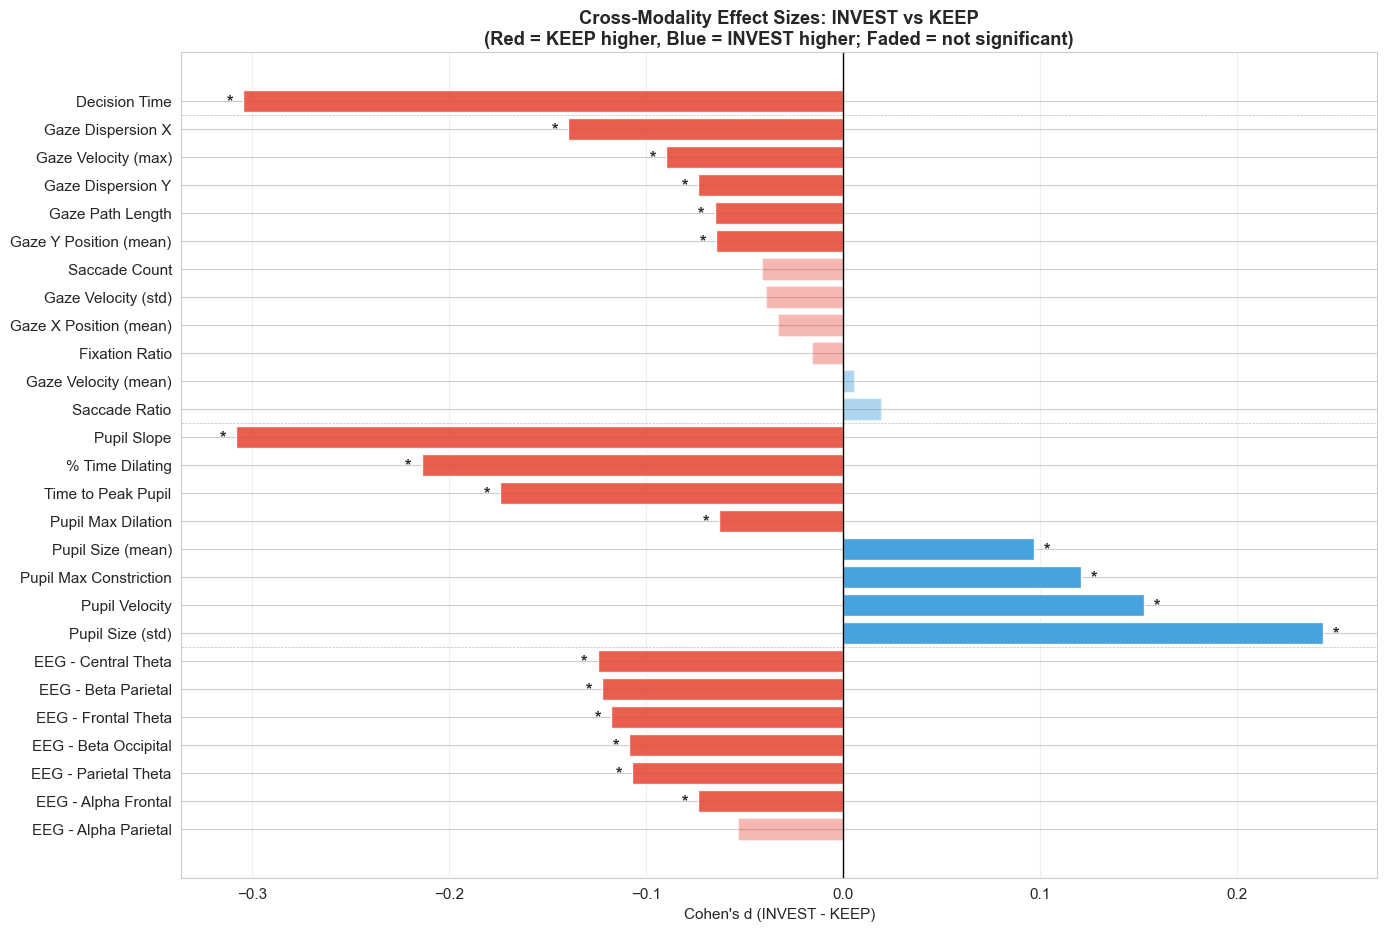


SUMMARY BY MODALITY

EEG: 7 features
  KEEP > INVEST: 7 | INVEST > KEEP: 0 | Significant: 6

Pupil: 8 features
  KEEP > INVEST: 4 | INVEST > KEEP: 4 | Significant: 8

Gaze: 11 features
  KEEP > INVEST: 9 | INVEST > KEEP: 2 | Significant: 5

Behavior: 1 features
  KEEP > INVEST: 1 | INVEST > KEEP: 0 | Significant: 1

FEATURES WITH SAME DIRECTION AS FRONTAL THETA (KEEP > INVEST, p < 0.05)
  EEG      | EEG - Alpha Frontal      : d = -0.0736
  EEG      | EEG - Parietal Theta     : d = -0.1073
  EEG      | EEG - Beta Occipital     : d = -0.1086
  EEG      | EEG - Frontal Theta      : d = -0.1179
  EEG      | EEG - Beta Parietal      : d = -0.1223
  EEG      | EEG - Central Theta      : d = -0.1246
  Pupil    | Pupil Max Dilation       : d = -0.0628
  Pupil    | Time to Peak Pupil       : d = -0.1741
  Pupil    | % Time Dilating          : d = -0.2140
  Pupil    | Pupil Slope              : d = -0.3083
  Gaze     | Gaze Y Position (mean)   : d = -0.0646
  Gaze     | Gaze Path Length        

In [7]:
# =============================================================================
# CROSS-MODALITY ANALYSIS: Does KEEP > INVEST pattern transfer to other modalities?
# =============================================================================
print("\n" + "="*70)
print("CROSS-MODALITY ANALYSIS: KEEP vs INVEST EFFECTS")
print("="*70)
print("\nQuestion: Does the KEEP > INVEST pattern seen in frontal theta")
print("also appear in pupil, gaze, or decision time?\n")

# Get physio and gaze columns that are in merged_with_eeg
available_physio = [c for c in physio_cols if c in merged_with_eeg.columns]
available_gaze = [c for c in gaze_cols if c in merged_with_eeg.columns]

# Key features to analyze across modalities - EXPANDED
key_features = {
    # EEG features
    'EEG - Frontal Theta': 'eeg_Theta_Frontal',
    'EEG - Central Theta': 'eeg_Theta_Central',
    'EEG - Parietal Theta': 'eeg_Theta_Parietal',
    'EEG - Beta Parietal': 'eeg_Beta_Parietal',
    'EEG - Beta Occipital': 'eeg_Beta_Occipital',
    'EEG - Alpha Frontal': 'eeg_Alpha_Frontal',
    'EEG - Alpha Parietal': 'eeg_Alpha_Parietal',
    # Behavior
    'Decision Time': 'decision_time',
}

# Add ALL pupil features if available
if available_physio:
    pupil_features = {
        'Pupil Size (mean)': 'pupil_mean',
        'Pupil Size (std)': 'pupil_std',
        'Pupil Slope': 'pupil_slope',
        'Pupil Velocity': 'pupil_velocity_mean',
        'Pupil Max Dilation': 'pupil_max_dilation_rate',
        'Pupil Max Constriction': 'pupil_max_constriction_rate',
        'Time to Peak Pupil': 'time_to_peak',
        '% Time Dilating': 'pct_time_dilating',
    }
    for name, pattern in pupil_features.items():
        matching = [c for c in available_physio if pattern in c]
        if matching:
            key_features[name] = matching[0]

# Add ALL gaze features if available
if available_gaze:
    gaze_features = {
        'Gaze Velocity (mean)': 'gaze_velocity_mean',
        'Gaze Velocity (std)': 'gaze_velocity_std',
        'Gaze Velocity (max)': 'gaze_velocity_max',
        'Fixation Ratio': 'fixation_ratio',
        'Saccade Ratio': 'saccade_ratio',
        'Saccade Count': 'saccade_count',
        'Gaze Dispersion X': 'gaze_dispersion_x',
        'Gaze Dispersion Y': 'gaze_dispersion_y',
        'Gaze Path Length': 'gaze_path_length',
        'Gaze X Position (mean)': 'gaze_x_mean',
        'Gaze Y Position (mean)': 'gaze_y_mean',
    }
    for name, col in gaze_features.items():
        if col in available_gaze:
            key_features[name] = col

# Compute effect sizes for each feature
cross_modal_results = []
for name, col in key_features.items():
    if col not in merged_with_eeg.columns:
        continue
    
    invest_vals = merged_with_eeg[merged_with_eeg['outcome'] == 1][col].dropna()
    keep_vals = merged_with_eeg[merged_with_eeg['outcome'] == 0][col].dropna()
    
    if len(invest_vals) < 10 or len(keep_vals) < 10:
        continue
    
    d = compute_cohens_d(invest_vals, keep_vals)
    t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
    
    # Determine modality for grouping
    if 'EEG' in name:
        modality = 'EEG'
    elif 'Pupil' in name or 'Dilat' in name or 'Time to Peak' in name:
        modality = 'Pupil'
    elif 'Gaze' in name or 'Fixation' in name or 'Saccade' in name:
        modality = 'Gaze'
    else:
        modality = 'Behavior'
    
    cross_modal_results.append({
        'Feature': name,
        'Column': col,
        'Modality': modality,
        'cohens_d': d,
        'p_value': p_val,
        'invest_mean': invest_vals.mean(),
        'keep_mean': keep_vals.mean(),
        'direction': 'KEEP higher' if d < 0 else 'INVEST higher',
        'significant': '*' if p_val < 0.05 else ''
    })

cross_modal_df = pd.DataFrame(cross_modal_results)

# Print results grouped by modality
print("Effect Sizes by Feature (INVEST - KEEP):")
print("=" * 85)
for modality in ['EEG', 'Pupil', 'Gaze', 'Behavior']:
    mod_df = cross_modal_df[cross_modal_df['Modality'] == modality]
    if len(mod_df) == 0:
        continue
    print(f"\n{modality.upper()}:")
    print("-" * 85)
    for _, row in mod_df.iterrows():
        sig = row['significant']
        direction = "←KEEP" if row['cohens_d'] < 0 else "INVEST→"
        print(f"  {row['Feature']:25s}: d = {row['cohens_d']:+.4f}  {direction:8s}  p = {row['p_value']:.4f} {sig}")

# Visualization - grouped by modality
fig, ax = plt.subplots(figsize=(14, max(8, len(cross_modal_df) * 0.35)))

# Sort by modality then by effect size
cross_modal_df['mod_order'] = cross_modal_df['Modality'].map({'EEG': 0, 'Pupil': 1, 'Gaze': 2, 'Behavior': 3})
cross_modal_df = cross_modal_df.sort_values(['mod_order', 'cohens_d'], ascending=[True, False])

colors = ['#E74C3C' if d < 0 else '#3498DB' for d in cross_modal_df['cohens_d']]
alphas = [0.9 if p < 0.05 else 0.4 for p in cross_modal_df['p_value']]

y_positions = range(len(cross_modal_df))
bars = ax.barh(y_positions, cross_modal_df['cohens_d'], color=colors)
for bar, alpha in zip(bars, alphas):
    bar.set_alpha(alpha)

ax.set_yticks(y_positions)
ax.set_yticklabels(cross_modal_df['Feature'])
ax.axvline(0, color='black', linestyle='-', linewidth=1)
ax.set_xlabel("Cohen's d (INVEST - KEEP)")
ax.set_title("Cross-Modality Effect Sizes: INVEST vs KEEP\n(Red = KEEP higher, Blue = INVEST higher; Faded = not significant)", 
             fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add modality separators
prev_mod = None
for i, (_, row) in enumerate(cross_modal_df.iterrows()):
    if prev_mod is not None and row['Modality'] != prev_mod:
        ax.axhline(i - 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    prev_mod = row['Modality']

# Add significance markers
for i, (_, row) in enumerate(cross_modal_df.iterrows()):
    if row['p_value'] < 0.05:
        x_pos = row['cohens_d'] + (0.005 if row['cohens_d'] > 0 else -0.005)
        ax.text(x_pos, i, '*', fontsize=12, fontweight='bold', va='center', 
                ha='left' if row['cohens_d'] > 0 else 'right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'cross_modality_effects.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary interpretation
print("\n" + "="*70)
print("SUMMARY BY MODALITY")
print("="*70)

for modality in ['EEG', 'Pupil', 'Gaze', 'Behavior']:
    mod_df = cross_modal_df[cross_modal_df['Modality'] == modality]
    if len(mod_df) == 0:
        continue
    n_keep = (mod_df['cohens_d'] < 0).sum()
    n_invest = (mod_df['cohens_d'] > 0).sum()
    n_sig = (mod_df['p_value'] < 0.05).sum()
    print(f"\n{modality}: {len(mod_df)} features")
    print(f"  KEEP > INVEST: {n_keep} | INVEST > KEEP: {n_invest} | Significant: {n_sig}")

# Check if theta pattern is unique or shared
print("\n" + "="*70)
print("FEATURES WITH SAME DIRECTION AS FRONTAL THETA (KEEP > INVEST, p < 0.05)")
print("="*70)
similar_sig = cross_modal_df[(cross_modal_df['cohens_d'] < 0) & 
                              (cross_modal_df['p_value'] < 0.05)]
if len(similar_sig) > 0:
    for _, row in similar_sig.iterrows():
        print(f"  {row['Modality']:8s} | {row['Feature']:25s}: d = {row['cohens_d']:.4f}")
else:
    print("  None found")

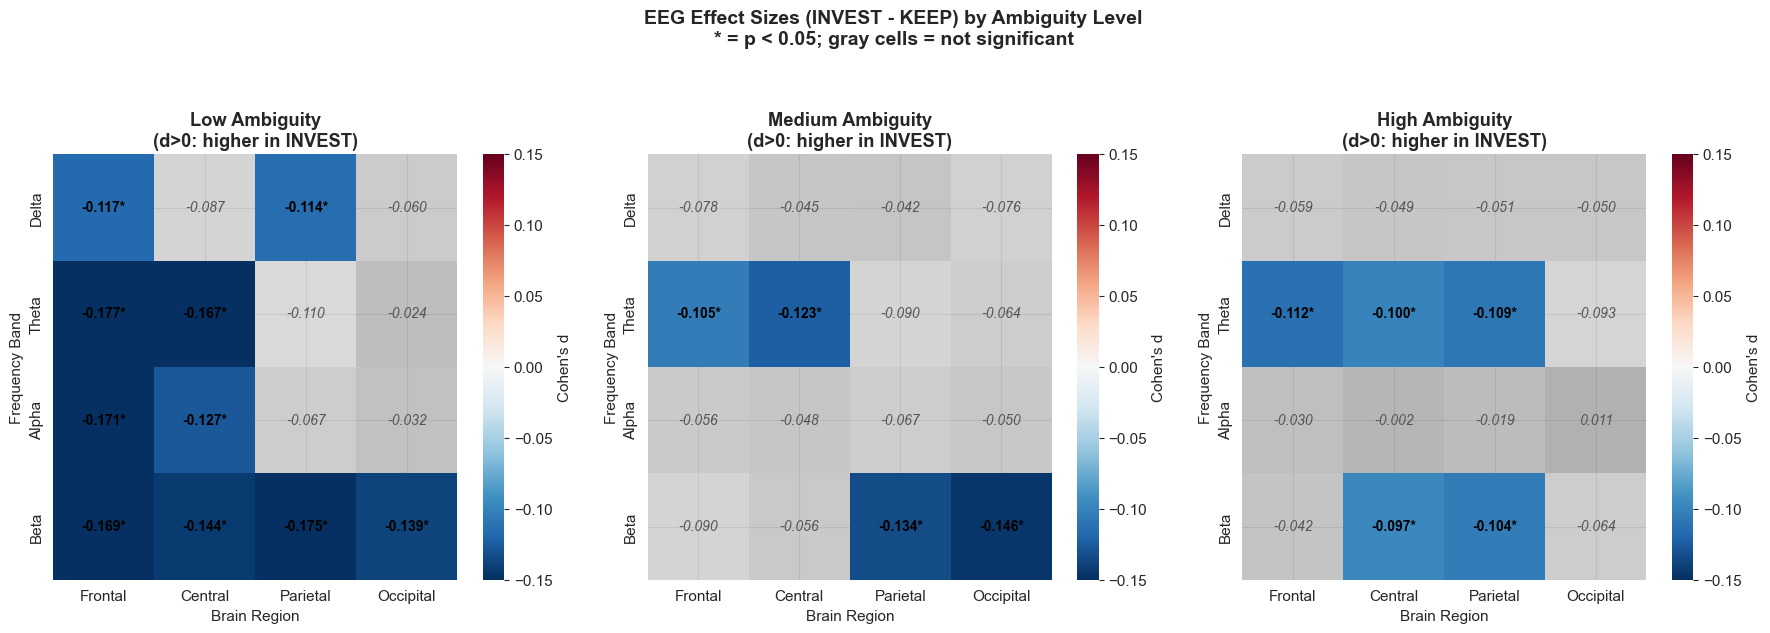

In [8]:
# Heatmap: Effect sizes by Band × Region × Ambiguity
# Non-significant cells (p >= 0.05) shown in gray with italic annotations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

band_order = ['Delta', 'Theta', 'Alpha', 'Beta']
region_order = ['Frontal', 'Central', 'Parietal', 'Occipital']

for idx, ambiguity in enumerate(['Low', 'Medium', 'High']):
    ax = axes[idx]
    amb_df = effect_df[effect_df['ambiguity'] == ambiguity]
    
    # Create pivot tables for effect sizes and p-values
    pivot_d = amb_df.pivot(index='band', columns='region', values='cohens_d')
    pivot_d = pivot_d.reindex(index=band_order, columns=region_order)
    
    pivot_p = amb_df.pivot(index='band', columns='region', values='p_value')
    pivot_p = pivot_p.reindex(index=band_order, columns=region_order)
    
    # Create mask for non-significant values
    sig_mask = pivot_p < 0.05
    
    # Create a masked version for non-significant values (will be gray)
    masked_data = np.where(sig_mask, pivot_d.values, np.nan)
    nonsig_data = np.where(~sig_mask, pivot_d.values, np.nan)
    
    # Plot significant values with RdBu_r colormap
    sns.heatmap(pivot_d, cmap='RdBu_r', center=0, annot=False,
                vmin=-0.15, vmax=0.15, ax=ax, cbar_kws={'label': "Cohen's d"},
                mask=~sig_mask)
    
    # Overlay non-significant values in gray
    sns.heatmap(pivot_d, cmap='Greys', center=0, annot=False,
                vmin=-0.3, vmax=0.3, ax=ax, cbar=False,
                mask=sig_mask, alpha=0.7)
    
    # Add annotations manually with different styles for sig vs non-sig
    for i, band in enumerate(band_order):
        for j, region in enumerate(region_order):
            d_val = pivot_d.loc[band, region]
            p_val = pivot_p.loc[band, region]
            is_sig = p_val < 0.05
            
            # Significant: bold black text; Non-significant: gray italic text
            if is_sig:
                ax.text(j + 0.5, i + 0.5, f'{d_val:.3f}*', 
                       ha='center', va='center', fontsize=10, fontweight='bold', color='black')
            else:
                ax.text(j + 0.5, i + 0.5, f'{d_val:.3f}', 
                       ha='center', va='center', fontsize=10, fontstyle='italic', color='#555555')
    
    ax.set_title(f'{ambiguity} Ambiguity\n(d>0: higher in INVEST)', fontweight='bold')
    ax.set_xlabel('Brain Region')
    ax.set_ylabel('Frequency Band')

plt.suptitle('EEG Effect Sizes (INVEST - KEEP) by Ambiguity Level\n* = p < 0.05; gray cells = not significant', 
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'eeg_effect_sizes_by_ambiguity.png', dpi=300, bbox_inches='tight')
plt.show()

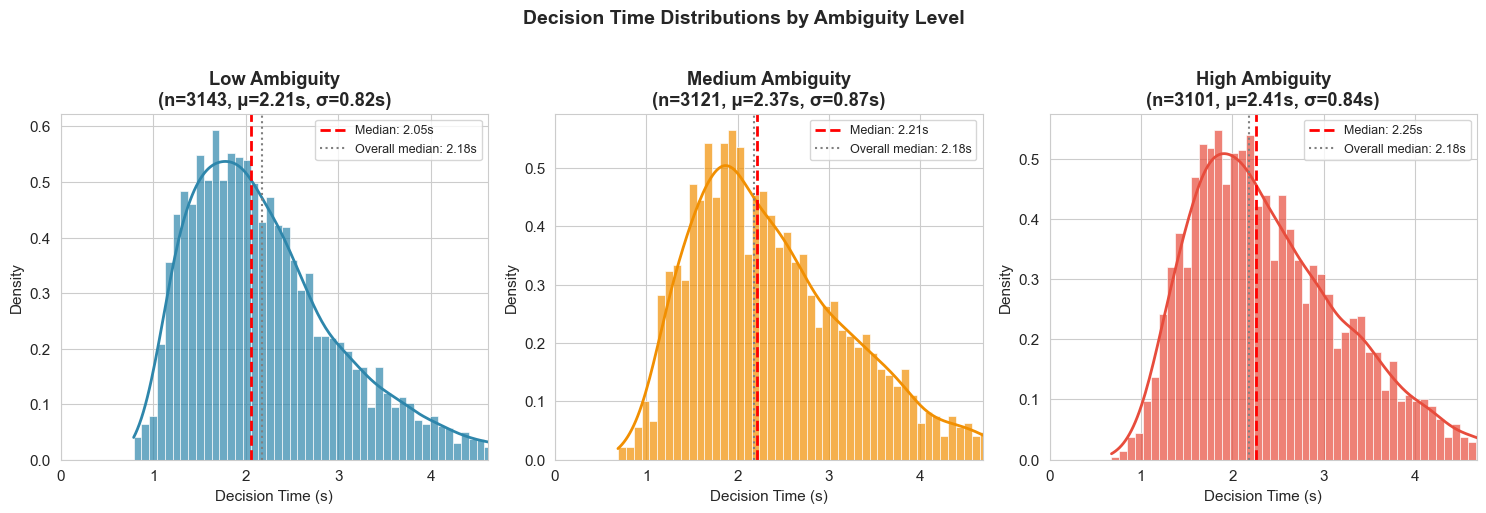


Decision Time Summary by Ambiguity Level (seconds):
------------------------------------------------------------
                 count   mean    std  median    min    max
ambiguity_group                                           
Low               3143  2.215  0.821   2.054  0.788  4.997
Medium            3121  2.373  0.865   2.210  0.688  4.997
High              3101  2.411  0.839   2.254  0.677  5.009


In [9]:
# Distribution of Decision Times by Ambiguity Level

# The column is 'decision_time' (in seconds), not 'reaction_time'
rt_column = 'decision_time'

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {'Low': '#2E86AB', 'Medium': '#F18F01', 'High': '#E74C3C'}

# Get overall RT stats for reference
overall_median = merged_with_eeg[rt_column].median()

for idx, ambiguity in enumerate(['Low', 'Medium', 'High']):
    ax = axes[idx]
    amb_df = merged_with_eeg[merged_with_eeg['ambiguity_group'] == ambiguity]
    rt_data = amb_df[rt_column].dropna()
    
    # Histogram with KDE using seaborn
    sns.histplot(rt_data, bins=50, stat='density', alpha=0.7, color=colors[ambiguity], 
                 edgecolor='white', ax=ax, kde=True, line_kws={'linewidth': 2, 'color': 'black'})
    
    # Add median line
    median_rt = rt_data.median()
    ax.axvline(median_rt, color='red', linestyle='--', linewidth=2, label=f'Median: {median_rt:.2f}s')
    ax.axvline(overall_median, color='gray', linestyle=':', linewidth=1.5, label=f'Overall median: {overall_median:.2f}s')
    
    ax.set_xlabel('Decision Time (s)')
    ax.set_ylabel('Density')
    ax.set_title(f'{ambiguity} Ambiguity\n(n={len(rt_data)}, μ={rt_data.mean():.2f}s, σ={rt_data.std():.2f}s)', 
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim([0, rt_data.quantile(0.99)])  # Trim outliers for visualization

plt.suptitle('Decision Time Distributions by Ambiguity Level', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'decision_time_by_ambiguity.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary statistics
print("\nDecision Time Summary by Ambiguity Level (seconds):")
print("-" * 60)
rt_stats = merged_with_eeg.groupby('ambiguity_group')[rt_column].agg(['count', 'mean', 'std', 'median', 'min', 'max'])
rt_stats = rt_stats.reindex(['Low', 'Medium', 'High'])
print(rt_stats.round(3).to_string())

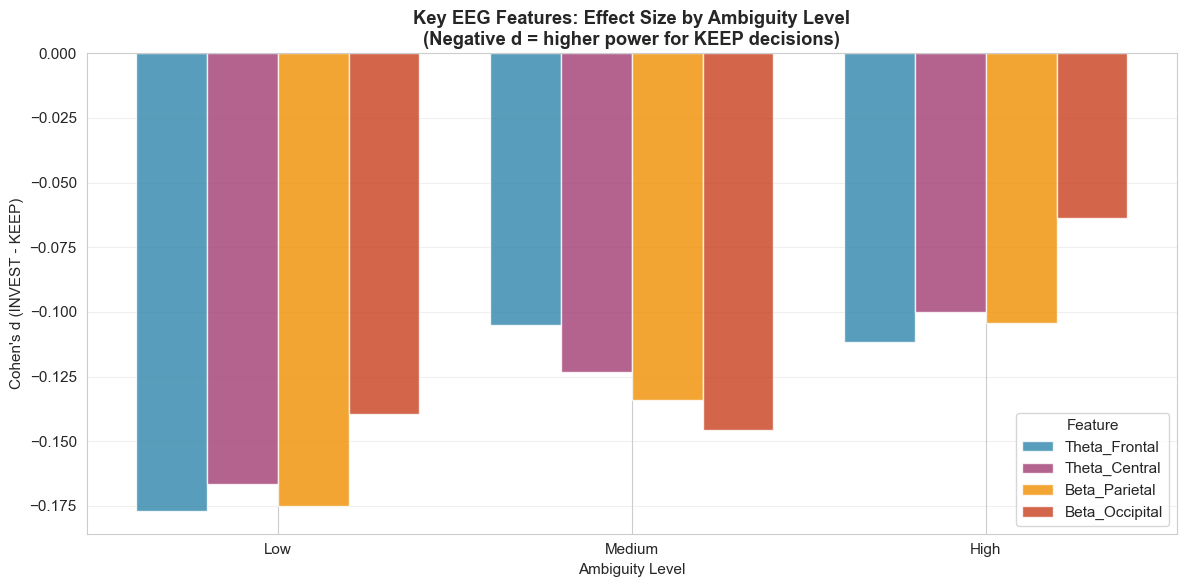

In [10]:
# Bar plot: Effect size change across ambiguity for key features
key_features = ['eeg_Theta_Frontal', 'eeg_Theta_Central', 'eeg_Beta_Parietal', 'eeg_Beta_Occipital']

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(3)  # Low, Medium, High
width = 0.2
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

for i, feat in enumerate(key_features):
    feat_df = effect_df[effect_df['feature'] == feat]
    # Ensure correct order
    values = [feat_df[feat_df['ambiguity'] == amb]['cohens_d'].values[0] for amb in ['Low', 'Medium', 'High']]
    offset = (i - len(key_features)/2 + 0.5) * width
    ax.bar(x + offset, values, width, label=feat.replace('eeg_', ''), color=colors[i], alpha=0.8)

ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_xlabel('Ambiguity Level')
ax.set_ylabel("Cohen's d (INVEST - KEEP)")
ax.set_title('Key EEG Features: Effect Size by Ambiguity Level\n(Negative d = higher power for KEEP decisions)', fontweight='bold')
ax.legend(title='Feature')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'key_eeg_features_by_ambiguity.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Analysis 2: EEG-Only Accuracy by Ambiguity Level

Does EEG contribute more when behavioral cues are less informative (high ambiguity)?

In [11]:
def run_single_modality_cv(X, y, subjects):
    """Run LOSO-CV for a single modality."""
    logo = LeaveOneGroupOut()
    accuracies = []
    
    for train_idx, test_idx in logo.split(X, y, subjects):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        
        clf = RandomForestClassifier(n_estimators=100, max_depth=5, 
                                     class_weight='balanced', random_state=42, n_jobs=-1)
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        accuracies.append(accuracy_score(y_test, y_pred))
    
    return np.array(accuracies)

# Run EEG-only, Behavior-only, and Physio-only for each ambiguity level
modality_results = []

imputer = SimpleImputer(strategy='mean')

for ambiguity in ['Low', 'Medium', 'High']:
    print(f"\nProcessing {ambiguity} ambiguity...")
    amb_df = merged_with_eeg[merged_with_eeg['ambiguity_group'] == ambiguity]
    
    y = amb_df['outcome'].values
    subjects = amb_df['subject_id'].values
    
    # EEG only
    X_eeg = imputer.fit_transform(amb_df[eeg_cols])
    eeg_accs = run_single_modality_cv(X_eeg, y, subjects)
    
    # Behavior only
    X_behavior = imputer.fit_transform(amb_df[behavior_cols])
    behavior_accs = run_single_modality_cv(X_behavior, y, subjects)
    
    # Physio (pupil) only
    X_physio = imputer.fit_transform(amb_df[physio_cols])
    physio_accs = run_single_modality_cv(X_physio, y, subjects)
    
    # Gaze only
    X_gaze = imputer.fit_transform(amb_df[gaze_cols])
    gaze_accs = run_single_modality_cv(X_gaze, y, subjects)
    
    for modality, accs in [('EEG', eeg_accs), ('Behavior', behavior_accs), 
                           ('Physio', physio_accs), ('Gaze', gaze_accs)]:
        modality_results.append({
            'ambiguity': ambiguity,
            'modality': modality,
            'accuracy_mean': accs.mean(),
            'accuracy_std': accs.std(),
            'accuracy_sem': accs.std() / np.sqrt(len(accs)),
            'n_subjects': len(accs)
        })

modality_acc_df = pd.DataFrame(modality_results)
print("\nDone!")


Processing Low ambiguity...

Processing Medium ambiguity...

Processing High ambiguity...

Done!


In [12]:
print("\n" + "="*70)
print("SINGLE-MODALITY ACCURACY BY AMBIGUITY LEVEL")
print("="*70)
print("\nQuestion: Does EEG contribute MORE when behavioral cues are less informative?\n")

pivot = modality_acc_df.pivot(index='modality', columns='ambiguity', values='accuracy_mean')
pivot = pivot[['Low', 'Medium', 'High']]  # Ensure order
print(pivot.round(3).to_string())

# Compute relative performance (compared to behavior)
print("\n" + "-"*50)
print("Relative to Behavior (EEG acc / Behavior acc):")
for amb in ['Low', 'Medium', 'High']:
    eeg_acc = modality_acc_df[(modality_acc_df['modality'] == 'EEG') & 
                              (modality_acc_df['ambiguity'] == amb)]['accuracy_mean'].values[0]
    beh_acc = modality_acc_df[(modality_acc_df['modality'] == 'Behavior') & 
                              (modality_acc_df['ambiguity'] == amb)]['accuracy_mean'].values[0]
    ratio = eeg_acc / beh_acc
    print(f"  {amb}: {ratio:.3f} (EEG={eeg_acc:.3f}, Behavior={beh_acc:.3f})")


SINGLE-MODALITY ACCURACY BY AMBIGUITY LEVEL

Question: Does EEG contribute MORE when behavioral cues are less informative?

ambiguity    Low  Medium   High
modality                       
Behavior   0.654   0.682  0.673
EEG        0.696   0.597  0.574
Gaze       0.680   0.629  0.632
Physio     0.553   0.520  0.583

--------------------------------------------------
Relative to Behavior (EEG acc / Behavior acc):
  Low: 1.064 (EEG=0.696, Behavior=0.654)
  Medium: 0.875 (EEG=0.597, Behavior=0.682)
  High: 0.853 (EEG=0.574, Behavior=0.673)


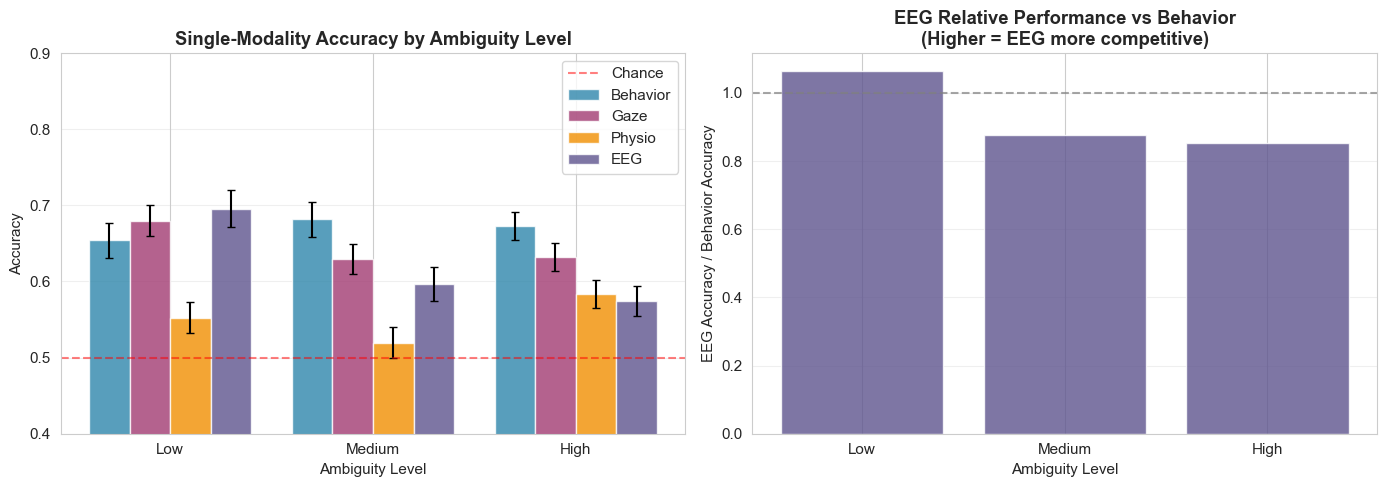

In [13]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Accuracy by modality and ambiguity
ax = axes[0]
modalities = ['Behavior', 'Gaze', 'Physio', 'EEG']
colors = {'Behavior': '#2E86AB', 'Gaze': '#A23B72', 'Physio': '#F18F01', 'EEG': '#5E548E'}

x = np.arange(3)
width = 0.2

for i, modality in enumerate(modalities):
    mod_df = modality_acc_df[modality_acc_df['modality'] == modality]
    values = [mod_df[mod_df['ambiguity'] == amb]['accuracy_mean'].values[0] for amb in ['Low', 'Medium', 'High']]
    errors = [mod_df[mod_df['ambiguity'] == amb]['accuracy_sem'].values[0] for amb in ['Low', 'Medium', 'High']]
    offset = (i - len(modalities)/2 + 0.5) * width
    ax.bar(x + offset, values, width, yerr=errors, label=modality, 
           color=colors[modality], alpha=0.8, capsize=3)

ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
ax.set_xticks(x)
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_xlabel('Ambiguity Level')
ax.set_ylabel('Accuracy')
ax.set_title('Single-Modality Accuracy by Ambiguity Level', fontweight='bold')
ax.legend()
ax.set_ylim([0.4, 0.9])
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: EEG relative performance
ax = axes[1]
eeg_rel = []
for amb in ['Low', 'Medium', 'High']:
    eeg_acc = modality_acc_df[(modality_acc_df['modality'] == 'EEG') & 
                              (modality_acc_df['ambiguity'] == amb)]['accuracy_mean'].values[0]
    beh_acc = modality_acc_df[(modality_acc_df['modality'] == 'Behavior') & 
                              (modality_acc_df['ambiguity'] == amb)]['accuracy_mean'].values[0]
    eeg_rel.append(eeg_acc / beh_acc)

ax.bar(['Low', 'Medium', 'High'], eeg_rel, color='#5E548E', alpha=0.8)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.7, label='Equal to Behavior')
ax.set_xlabel('Ambiguity Level')
ax.set_ylabel('EEG Accuracy / Behavior Accuracy')
ax.set_title('EEG Relative Performance vs Behavior\n(Higher = EEG more competitive)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'modality_accuracy_by_ambiguity.png', dpi=300, bbox_inches='tight')
plt.show()

### 3.1 Late Fusion: Gaze + Physio + EEG (Without Behavior)

Can we match or exceed behavioral accuracy using only non-behavioral signals? This tests whether the neural and physiological signals together can capture decision-relevant information independently of explicit behavioral features like decision time.

In [14]:
# =============================================================================
# LATE FUSION: GAZE + PHYSIO + EEG (without Behavior)
# =============================================================================
print("\n" + "="*70)
print("LATE FUSION: GAZE + PHYSIO + EEG (WITHOUT BEHAVIOR)")
print("="*70)
print("\nQuestion: Can non-behavioral signals together match or exceed")
print("behavioral accuracy alone?\n")

# Late fusion results storage
late_fusion_results = []

for ambiguity in ['Low', 'Medium', 'High']:
    print(f"\nProcessing {ambiguity} ambiguity...")
    amb_df = merged_with_eeg[merged_with_eeg['ambiguity_group'] == ambiguity]
    
    y = amb_df['outcome'].values
    subjects = amb_df['subject_id'].values
    
    # Combine Gaze + Physio + EEG features (excluding behavior)
    non_behavior_cols = gaze_cols + physio_cols + eeg_cols
    X_non_behavior = imputer.fit_transform(amb_df[non_behavior_cols])
    
    # Run late fusion CV
    non_behavior_accs = run_single_modality_cv(X_non_behavior, y, subjects)
    
    late_fusion_results.append({
        'ambiguity': ambiguity,
        'modality': 'Gaze+Physio+EEG',
        'accuracy_mean': non_behavior_accs.mean(),
        'accuracy_std': non_behavior_accs.std(),
        'accuracy_sem': non_behavior_accs.std() / np.sqrt(len(non_behavior_accs)),
        'n_subjects': len(non_behavior_accs),
        'accuracies': non_behavior_accs  # Store for statistical tests
    })

late_fusion_df = pd.DataFrame(late_fusion_results)
print("\nDone!")

# Print results
print("\n" + "-"*70)
print("LATE FUSION ACCURACY (Gaze + Physio + EEG):")
print("-"*70)
for amb in ['Low', 'Medium', 'High']:
    lf_acc = late_fusion_df[late_fusion_df['ambiguity'] == amb]['accuracy_mean'].values[0]
    lf_sem = late_fusion_df[late_fusion_df['ambiguity'] == amb]['accuracy_sem'].values[0]
    beh_acc = modality_acc_df[(modality_acc_df['modality'] == 'Behavior') & 
                              (modality_acc_df['ambiguity'] == amb)]['accuracy_mean'].values[0]
    ratio = lf_acc / beh_acc
    print(f"  {amb}: {lf_acc:.3f} ± {lf_sem:.3f} (vs Behavior: {beh_acc:.3f}, ratio: {ratio:.3f})")


LATE FUSION: GAZE + PHYSIO + EEG (WITHOUT BEHAVIOR)

Question: Can non-behavioral signals together match or exceed
behavioral accuracy alone?


Processing Low ambiguity...

Processing Medium ambiguity...

Processing High ambiguity...

Done!

----------------------------------------------------------------------
LATE FUSION ACCURACY (Gaze + Physio + EEG):
----------------------------------------------------------------------
  Low: 0.688 ± 0.021 (vs Behavior: 0.654, ratio: 1.052)
  Medium: 0.613 ± 0.021 (vs Behavior: 0.682, ratio: 0.899)
  High: 0.641 ± 0.017 (vs Behavior: 0.673, ratio: 0.953)


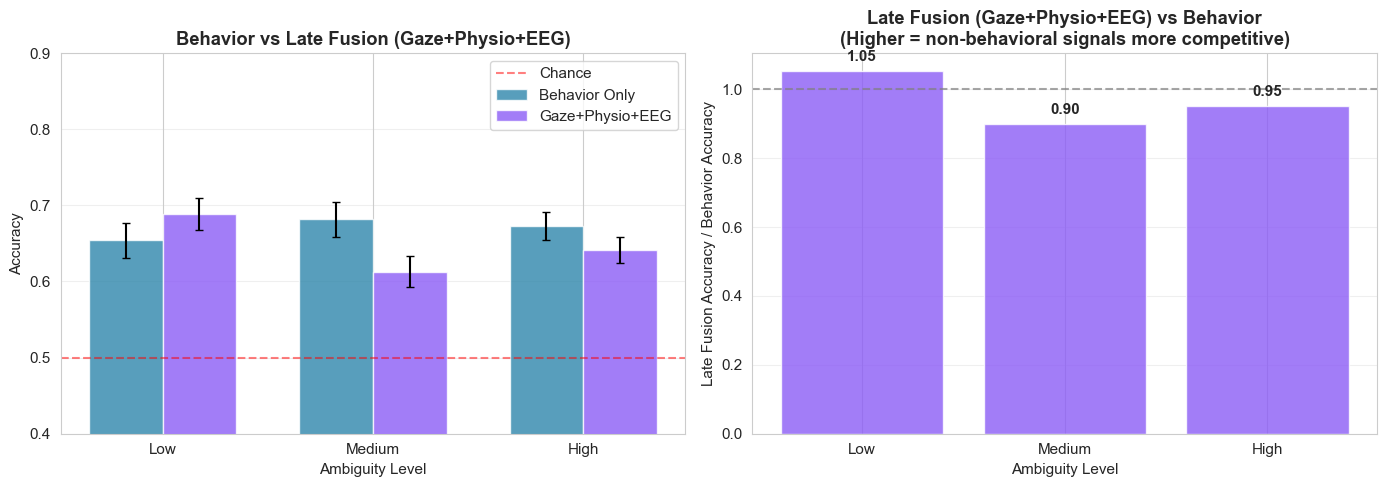


INTERPRETATION
  Low Ambiguity: ratio = 1.052 - Late Fusion EXCEEDS Behavior
  Medium Ambiguity: ratio = 0.899 - Late Fusion BELOW Behavior
  High Ambiguity: ratio = 0.953 - Late Fusion MATCHES Behavior (~5% within)


In [26]:
# Visualization: Late Fusion vs Behavior comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar chart comparing Behavior vs Late Fusion (Gaze+Physio+EEG) by ambiguity
ax = axes[0]
x = np.arange(3)
width = 0.35

behavior_vals = [modality_acc_df[(modality_acc_df['modality'] == 'Behavior') & 
                                  (modality_acc_df['ambiguity'] == amb)]['accuracy_mean'].values[0] 
                 for amb in ['Low', 'Medium', 'High']]
behavior_errs = [modality_acc_df[(modality_acc_df['modality'] == 'Behavior') & 
                                  (modality_acc_df['ambiguity'] == amb)]['accuracy_sem'].values[0] 
                 for amb in ['Low', 'Medium', 'High']]

lf_vals = [late_fusion_df[late_fusion_df['ambiguity'] == amb]['accuracy_mean'].values[0] 
           for amb in ['Low', 'Medium', 'High']]
lf_errs = [late_fusion_df[late_fusion_df['ambiguity'] == amb]['accuracy_sem'].values[0] 
           for amb in ['Low', 'Medium', 'High']]

ax.bar(x - width/2, behavior_vals, width, yerr=behavior_errs, label='Behavior Only', 
       color='#2E86AB', alpha=0.8, capsize=3)
ax.bar(x + width/2, lf_vals, width, yerr=lf_errs, label='Gaze+Physio+EEG', 
       color='#8B5CF6', alpha=0.8, capsize=3)

ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
ax.set_xticks(x)
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_xlabel('Ambiguity Level')
ax.set_ylabel('Accuracy')
ax.set_title('Behavior vs Late Fusion (Gaze+Physio+EEG)', fontweight='bold')
ax.legend()
ax.set_ylim([0.4, 0.9])
ax.grid(True, alpha=0.3, axis='y')

# Plot 2: Relative performance (Late Fusion / Behavior) - similar to EEG plot
ax = axes[1]
lf_rel = []
for amb in ['Low', 'Medium', 'High']:
    lf_acc = late_fusion_df[late_fusion_df['ambiguity'] == amb]['accuracy_mean'].values[0]
    beh_acc = modality_acc_df[(modality_acc_df['modality'] == 'Behavior') & 
                              (modality_acc_df['ambiguity'] == amb)]['accuracy_mean'].values[0]
    lf_rel.append(lf_acc / beh_acc)

bars = ax.bar(['Low', 'Medium', 'High'], lf_rel, color='#8B5CF6', alpha=0.8)
ax.axhline(1.0, color='gray', linestyle='--', alpha=0.7, label='Equal to Behavior')
ax.set_xlabel('Ambiguity Level')
ax.set_ylabel('Late Fusion Accuracy / Behavior Accuracy')
ax.set_title('Late Fusion (Gaze+Physio+EEG) vs Behavior\n(Higher = non-behavioral signals more competitive)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, val in zip(bars, lf_rel):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'late_fusion_vs_behavior_by_ambiguity.png', dpi=300, bbox_inches='tight')
plt.show()

# Print summary interpretation
print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)
for amb, ratio in zip(['Low', 'Medium', 'High'], lf_rel):
    if ratio > 1.0:
        interp = "Late Fusion EXCEEDS Behavior"
    elif ratio > 0.95:
        interp = "Late Fusion MATCHES Behavior (~5% within)"
    else:
        interp = "Late Fusion BELOW Behavior"
    print(f"  {amb} Ambiguity: ratio = {ratio:.3f} - {interp}")


LATE FUSION: GAZE + PHYSIO (Pupil + Gaze features)

Processing Low ambiguity...


/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.w


Processing Medium ambiguity...


/Users/pranmodu/Projects/columbia/liinc_eye/venv/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(



Processing High ambiguity...

Done!


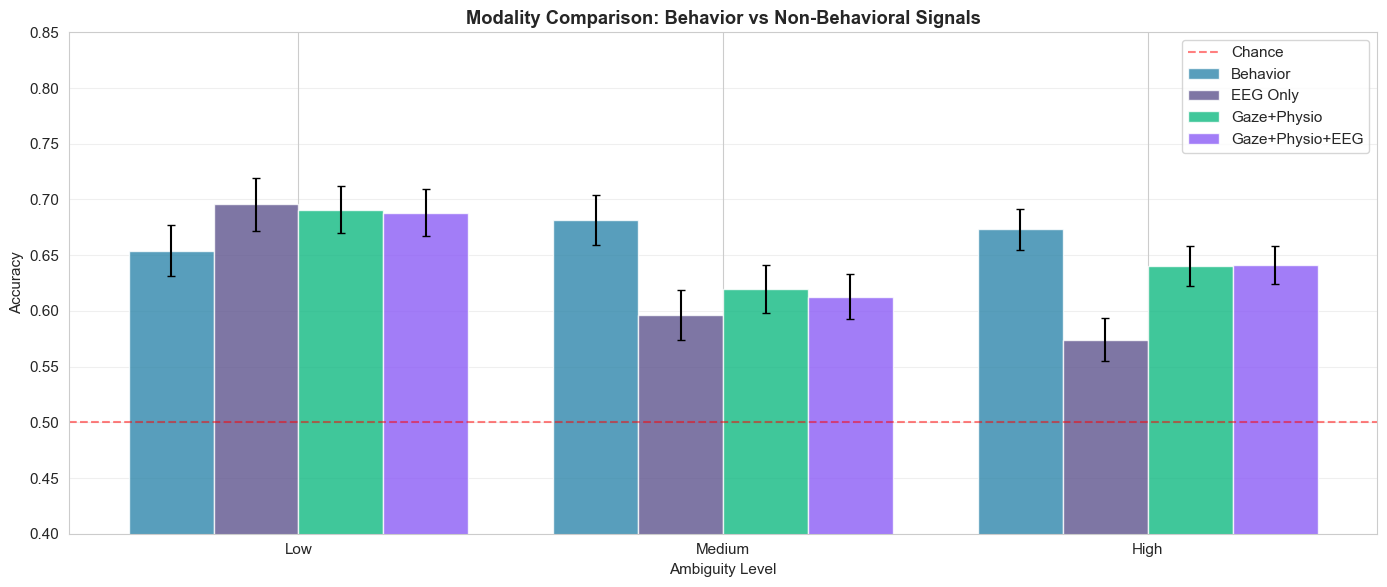


SUMMARY: ACCURACY BY MODALITY AND AMBIGUITY

Ambiguity  Behavior     EEG          Gaze+Physio  G+P+EEG     
----------------------------------------------------------
Low        0.654        0.696        0.691        0.688       
Medium     0.682        0.597        0.620        0.613       
High       0.673        0.574        0.641        0.641       

Saved: ../../data/results/main/eeg_integration/eeg_deep_dive/late_fusion_gpe_accuracy_by_ambiguity.csv
Saved: ../../data/results/main/eeg_integration/eeg_deep_dive/late_fusion_gaze_physio_accuracy_by_ambiguity.csv


In [27]:
# =============================================================================
# LATE FUSION: GAZE + PHYSIO (without EEG or Behavior)
# =============================================================================
print("\n" + "="*70)
print("LATE FUSION: GAZE + PHYSIO (Pupil + Gaze features)")
print("="*70)

# Run Gaze + Physio late fusion
gaze_physio_results = []

for ambiguity in ['Low', 'Medium', 'High']:
    print(f"\nProcessing {ambiguity} ambiguity...")
    amb_df = merged_with_eeg[merged_with_eeg['ambiguity_group'] == ambiguity]
    
    y = amb_df['outcome'].values
    subjects = amb_df['subject_id'].values
    
    # Combine Gaze + Physio features only
    gaze_physio_cols = gaze_cols + physio_cols
    X_gaze_physio = imputer.fit_transform(amb_df[gaze_physio_cols])
    
    # Run late fusion CV
    gaze_physio_accs = run_single_modality_cv(X_gaze_physio, y, subjects)
    
    gaze_physio_results.append({
        'ambiguity': ambiguity,
        'modality': 'Gaze+Physio',
        'accuracy_mean': gaze_physio_accs.mean(),
        'accuracy_std': gaze_physio_accs.std(),
        'accuracy_sem': gaze_physio_accs.std() / np.sqrt(len(gaze_physio_accs)),
        'n_subjects': len(gaze_physio_accs)
    })

gaze_physio_df = pd.DataFrame(gaze_physio_results)
print("\nDone!")

# Comparison: Behavior vs EEG vs Gaze+Physio vs Gaze+Physio+EEG
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(3)
width = 0.2

# Get accuracy values for each modality
beh_vals = [modality_acc_df[(modality_acc_df['modality'] == 'Behavior') & 
                             (modality_acc_df['ambiguity'] == amb)]['accuracy_mean'].values[0] 
            for amb in ['Low', 'Medium', 'High']]
beh_errs = [modality_acc_df[(modality_acc_df['modality'] == 'Behavior') & 
                             (modality_acc_df['ambiguity'] == amb)]['accuracy_sem'].values[0] 
            for amb in ['Low', 'Medium', 'High']]

eeg_vals = [modality_acc_df[(modality_acc_df['modality'] == 'EEG') & 
                             (modality_acc_df['ambiguity'] == amb)]['accuracy_mean'].values[0] 
            for amb in ['Low', 'Medium', 'High']]
eeg_errs = [modality_acc_df[(modality_acc_df['modality'] == 'EEG') & 
                             (modality_acc_df['ambiguity'] == amb)]['accuracy_sem'].values[0] 
            for amb in ['Low', 'Medium', 'High']]

gp_vals = [gaze_physio_df[gaze_physio_df['ambiguity'] == amb]['accuracy_mean'].values[0] 
           for amb in ['Low', 'Medium', 'High']]
gp_errs = [gaze_physio_df[gaze_physio_df['ambiguity'] == amb]['accuracy_sem'].values[0] 
           for amb in ['Low', 'Medium', 'High']]

lf_vals = [late_fusion_df[late_fusion_df['ambiguity'] == amb]['accuracy_mean'].values[0] 
           for amb in ['Low', 'Medium', 'High']]
lf_errs = [late_fusion_df[late_fusion_df['ambiguity'] == amb]['accuracy_sem'].values[0] 
           for amb in ['Low', 'Medium', 'High']]

bars0 = ax.bar(x - 1.5*width, beh_vals, width, yerr=beh_errs, label='Behavior', 
               color='#2E86AB', alpha=0.8, capsize=3)
bars1 = ax.bar(x - 0.5*width, eeg_vals, width, yerr=eeg_errs, label='EEG Only', 
               color='#5E548E', alpha=0.8, capsize=3)
bars2 = ax.bar(x + 0.5*width, gp_vals, width, yerr=gp_errs, label='Gaze+Physio', 
               color='#10B981', alpha=0.8, capsize=3)
bars3 = ax.bar(x + 1.5*width, lf_vals, width, yerr=lf_errs, label='Gaze+Physio+EEG', 
               color='#8B5CF6', alpha=0.8, capsize=3)

ax.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
ax.set_xticks(x)
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_xlabel('Ambiguity Level')
ax.set_ylabel('Accuracy')
ax.set_title('Modality Comparison: Behavior vs Non-Behavioral Signals', fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim([0.4, 0.85])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'all_modalities_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Summary table
print("\n" + "="*70)
print("SUMMARY: ACCURACY BY MODALITY AND AMBIGUITY")
print("="*70)
print(f"\n{'Ambiguity':<10} {'Behavior':<12} {'EEG':<12} {'Gaze+Physio':<12} {'G+P+EEG':<12}")
print("-"*58)
for amb in ['Low', 'Medium', 'High']:
    beh_acc = modality_acc_df[(modality_acc_df['modality'] == 'Behavior') & 
                              (modality_acc_df['ambiguity'] == amb)]['accuracy_mean'].values[0]
    eeg_acc = modality_acc_df[(modality_acc_df['modality'] == 'EEG') & 
                              (modality_acc_df['ambiguity'] == amb)]['accuracy_mean'].values[0]
    gp_acc = gaze_physio_df[gaze_physio_df['ambiguity'] == amb]['accuracy_mean'].values[0]
    lf_acc = late_fusion_df[late_fusion_df['ambiguity'] == amb]['accuracy_mean'].values[0]
    print(f"{amb:<10} {beh_acc:<12.3f} {eeg_acc:<12.3f} {gp_acc:<12.3f} {lf_acc:<12.3f}")

# Save results
late_fusion_save_df = late_fusion_df.drop(columns=['accuracies'])
late_fusion_save_df.to_csv(OUTPUT_DIR / 'late_fusion_gpe_accuracy_by_ambiguity.csv', index=False)
gaze_physio_df.to_csv(OUTPUT_DIR / 'late_fusion_gaze_physio_accuracy_by_ambiguity.csv', index=False)
print(f"\nSaved: {OUTPUT_DIR / 'late_fusion_gpe_accuracy_by_ambiguity.csv'}")
print(f"Saved: {OUTPUT_DIR / 'late_fusion_gaze_physio_accuracy_by_ambiguity.csv'}")

## 4. Analysis 3: Detailed Theta Analysis

Deep dive into theta band across regions and ambiguity levels.

In [17]:
# Group-level theta power comparison
theta_cols = [c for c in eeg_cols if 'Theta' in c]

print("\n" + "="*70)
print("THETA POWER BY AMBIGUITY AND CHOICE")
print("="*70)

for col in theta_cols:
    print(f"\n{col}:")
    for amb in ['Low', 'Medium', 'High']:
        amb_df = merged_with_eeg[merged_with_eeg['ambiguity_group'] == amb]
        invest_mean = amb_df[amb_df['outcome'] == 1][col].mean()
        keep_mean = amb_df[amb_df['outcome'] == 0][col].mean()
        diff = keep_mean - invest_mean
        print(f"  {amb}: INVEST={invest_mean:.4f}, KEEP={keep_mean:.4f}, diff={diff:+.4f}")


THETA POWER BY AMBIGUITY AND CHOICE

eeg_Theta_Frontal:
  Low: INVEST=0.0474, KEEP=0.0657, diff=+0.0183
  Medium: INVEST=0.0476, KEEP=0.0561, diff=+0.0085
  High: INVEST=0.0467, KEEP=0.0570, diff=+0.0103

eeg_Theta_Central:
  Low: INVEST=0.0434, KEEP=0.0557, diff=+0.0123
  Medium: INVEST=0.0431, KEEP=0.0522, diff=+0.0091
  High: INVEST=0.0444, KEEP=0.0534, diff=+0.0090

eeg_Theta_Parietal:
  Low: INVEST=0.0475, KEEP=0.0556, diff=+0.0081
  Medium: INVEST=0.0476, KEEP=0.0543, diff=+0.0067
  High: INVEST=0.0476, KEEP=0.0574, diff=+0.0097

eeg_Theta_Occipital:
  Low: INVEST=0.0584, KEEP=0.0606, diff=+0.0021
  Medium: INVEST=0.0575, KEEP=0.0631, diff=+0.0055
  High: INVEST=0.0576, KEEP=0.0662, diff=+0.0087


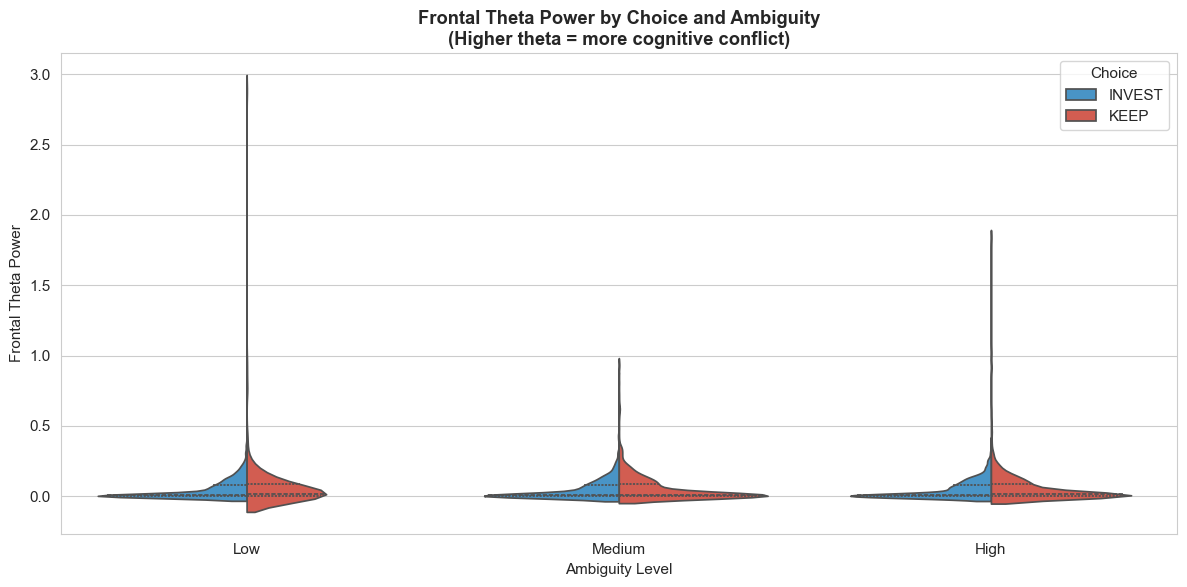

In [18]:
# Violin plot: Theta-Frontal distribution by choice and ambiguity
fig, ax = plt.subplots(figsize=(12, 6))

# Prepare data for seaborn
plot_df = merged_with_eeg[['ambiguity_group', 'outcome', 'eeg_Theta_Frontal']].copy()
plot_df['choice'] = plot_df['outcome'].map({0: 'KEEP', 1: 'INVEST'})
plot_df['ambiguity_group'] = pd.Categorical(plot_df['ambiguity_group'], 
                                            categories=['Low', 'Medium', 'High'], ordered=True)

sns.violinplot(data=plot_df, x='ambiguity_group', y='eeg_Theta_Frontal', 
               hue='choice', split=True, inner='quart', palette={'INVEST': '#3498DB', 'KEEP': '#E74C3C'},
               ax=ax)

ax.set_xlabel('Ambiguity Level')
ax.set_ylabel('Frontal Theta Power')
ax.set_title('Frontal Theta Power by Choice and Ambiguity\n(Higher theta = more cognitive conflict)', fontweight='bold')
ax.legend(title='Choice')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'theta_frontal_violin.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Analysis 4: Fronto-Parietal Coherence (Placeholder)

This requires raw EEG data to compute phase-locking values. Adding structure for future implementation.

In [19]:
# Load raw EEG for coherence analysis
print("\n" + "="*70)
print("FRONTO-PARIETAL COHERENCE ANALYSIS")
print("="*70)

from src.features.eeg_features import PREPROCESSED_EEG_PRE, PREPROCESSED_EEG_POST

# Use pre-decision (display window) for coherence analysis
EEG_PATH = PREPROCESSED_EEG_PRE

if EEG_PATH.exists():
    print(f"Loading raw EEG data for coherence analysis...")
    print(f"  File: {EEG_PATH}")
    with open(EEG_PATH, 'rb') as f:
        raw_eeg_df = pickle.load(f)
    print(f"Loaded {len(raw_eeg_df)} trials")
    print(f"EEG shape per trial: {raw_eeg_df.iloc[0]['eeg'].shape}")
else:
    print(f"Raw EEG file not found at {EEG_PATH}. Skipping coherence analysis.")
    raw_eeg_df = None


FRONTO-PARIETAL COHERENCE ANALYSIS
Loading raw EEG data for coherence analysis...
  File: /Users/pranmodu/Projects/columbia/liinc_eye/data/eeg/display_window_2s.pkl
Loaded 10212 trials
EEG shape per trial: (20, 512)


In [20]:
def compute_coherence(signal1, signal2, fs=256, nperseg=128):
    """Compute magnitude-squared coherence between two signals."""
    freqs, coh = signal.coherence(signal1, signal2, fs=fs, nperseg=nperseg)
    return freqs, coh

def compute_band_coherence(signal1, signal2, band=(4, 8), fs=256):
    """Compute average coherence within a frequency band."""
    freqs, coh = compute_coherence(signal1, signal2, fs=fs)
    band_mask = (freqs >= band[0]) & (freqs <= band[1])
    return np.mean(coh[band_mask])

if raw_eeg_df is not None:
    # Get channel indices
    fz_idx = CHANNEL_NAMES.index('Fz')
    pz_idx = CHANNEL_NAMES.index('Pz')
    
    print(f"Computing Fz-Pz theta coherence...")
    print(f"  Fz index: {fz_idx}, Pz index: {pz_idx}")
    
    # Sample a few trials to check
    sample_trials = raw_eeg_df.head(100)
    coherences = []
    
    for _, row in sample_trials.iterrows():
        eeg = row['eeg']  # (channels, time)
        fz_signal = eeg[fz_idx, :]
        pz_signal = eeg[pz_idx, :]
        
        theta_coh = compute_band_coherence(fz_signal, pz_signal, band=(4, 8))
        coherences.append(theta_coh)
    
    print(f"  Sample theta coherence (Fz-Pz): {np.mean(coherences):.4f} ± {np.std(coherences):.4f}")
    print("\n  (Full coherence analysis would extract this for all trials and compare by choice/ambiguity)")

Computing Fz-Pz theta coherence...
  Fz index: 12, Pz index: 10
  Sample theta coherence (Fz-Pz): nan ± nan

  (Full coherence analysis would extract this for all trials and compare by choice/ambiguity)


In [21]:
# Extract coherence features for all trials (if raw EEG available)
if raw_eeg_df is not None:
    print("\nExtracting Fz-Pz theta coherence for all trials...")
    
    coherence_data = []
    
    for idx, row in raw_eeg_df.iterrows():
        if idx % 2000 == 0:
            print(f"  Processing trial {idx}/{len(raw_eeg_df)}...")
        
        eeg = row['eeg']
        trial_id = f"{row['trial_id']}_{row['subject_date_id']}"
        
        # Fz-Pz theta coherence
        fz_pz_theta = compute_band_coherence(eeg[fz_idx, :], eeg[pz_idx, :], band=(4, 8))
        
        # F3-P3 theta coherence (left hemisphere)
        f3_idx = CHANNEL_NAMES.index('F3')
        p3_idx = CHANNEL_NAMES.index('P3')
        f3_p3_theta = compute_band_coherence(eeg[f3_idx, :], eeg[p3_idx, :], band=(4, 8))
        
        # F4-P4 theta coherence (right hemisphere)
        f4_idx = CHANNEL_NAMES.index('F4')
        p4_idx = CHANNEL_NAMES.index('P4')
        f4_p4_theta = compute_band_coherence(eeg[f4_idx, :], eeg[p4_idx, :], band=(4, 8))
        
        coherence_data.append({
            'trial_id': trial_id,
            'fz_pz_theta_coh': fz_pz_theta,
            'f3_p3_theta_coh': f3_p3_theta,
            'f4_p4_theta_coh': f4_p4_theta,
            'mean_fp_theta_coh': np.mean([fz_pz_theta, f3_p3_theta, f4_p4_theta])
        })
    
    coherence_df = pd.DataFrame(coherence_data)
    print(f"\nExtracted coherence for {len(coherence_df)} trials")
    
    # Merge with behavioral data
    merged_coherence = merged_with_eeg.merge(coherence_df, on='trial_id', how='inner')
    print(f"Merged dataset: {len(merged_coherence)} trials")


Extracting Fz-Pz theta coherence for all trials...
  Processing trial 0/10212...
  Processing trial 2000/10212...
  Processing trial 4000/10212...
  Processing trial 6000/10212...
  Processing trial 8000/10212...
  Processing trial 10000/10212...

Extracted coherence for 10212 trials
Merged dataset: 9365 trials


In [22]:
# Analyze coherence by choice and ambiguity
if raw_eeg_df is not None and len(coherence_df) > 0:
    print("\n" + "="*70)
    print("FRONTO-PARIETAL THETA COHERENCE RESULTS")
    print("="*70)
    
    coh_cols = ['fz_pz_theta_coh', 'f3_p3_theta_coh', 'f4_p4_theta_coh', 'mean_fp_theta_coh']
    
    coh_results = []
    for amb in ['Low', 'Medium', 'High']:
        amb_df = merged_coherence[merged_coherence['ambiguity_group'] == amb]
        invest_df = amb_df[amb_df['outcome'] == 1]
        keep_df = amb_df[amb_df['outcome'] == 0]
        
        for col in coh_cols:
            invest_vals = invest_df[col].dropna()
            keep_vals = keep_df[col].dropna()
            
            d = compute_cohens_d(invest_vals, keep_vals)
            t_stat, p_val = stats.ttest_ind(invest_vals, keep_vals)
            
            coh_results.append({
                'ambiguity': amb,
                'feature': col,
                'cohens_d': d,
                'p_value': p_val,
                'invest_mean': invest_vals.mean(),
                'keep_mean': keep_vals.mean()
            })
    
    coh_results_df = pd.DataFrame(coh_results)
    
    # Focus on mean fronto-parietal coherence
    print("\nMean Fronto-Parietal Theta Coherence by Ambiguity and Choice:")
    mean_fp = coh_results_df[coh_results_df['feature'] == 'mean_fp_theta_coh']
    print(mean_fp[['ambiguity', 'cohens_d', 'p_value', 'invest_mean', 'keep_mean']].to_string(index=False))


FRONTO-PARIETAL THETA COHERENCE RESULTS

Mean Fronto-Parietal Theta Coherence by Ambiguity and Choice:
ambiguity  cohens_d  p_value  invest_mean  keep_mean
      Low -0.106347 0.067155     0.376522   0.395864
   Medium  0.026616 0.586998     0.380863   0.375998
     High -0.008163 0.865591     0.385386   0.386917


## 6. Save Results

In [23]:
# Save all results
effect_df.to_csv(OUTPUT_DIR / 'eeg_effect_sizes_by_ambiguity.csv', index=False)
modality_acc_df.to_csv(OUTPUT_DIR / 'modality_accuracy_by_ambiguity.csv', index=False)

if raw_eeg_df is not None and 'coh_results_df' in dir():
    coh_results_df.to_csv(OUTPUT_DIR / 'coherence_results_by_ambiguity.csv', index=False)
    coherence_df.to_csv(OUTPUT_DIR / 'coherence_features_all_trials.csv', index=False)

print("\n" + "="*70)
print("FILES SAVED")
print("="*70)
print(f"  - {OUTPUT_DIR / 'eeg_effect_sizes_by_ambiguity.csv'}")
print(f"  - {OUTPUT_DIR / 'modality_accuracy_by_ambiguity.csv'}")
print(f"  - {OUTPUT_DIR / 'eeg_effect_sizes_by_ambiguity.png'}")
print(f"  - {OUTPUT_DIR / 'key_eeg_features_by_ambiguity.png'}")
print(f"  - {OUTPUT_DIR / 'modality_accuracy_by_ambiguity.png'}")
print(f"  - {OUTPUT_DIR / 'theta_frontal_violin.png'}")


FILES SAVED
  - ../../data/results/main/eeg_integration/eeg_deep_dive/eeg_effect_sizes_by_ambiguity.csv
  - ../../data/results/main/eeg_integration/eeg_deep_dive/modality_accuracy_by_ambiguity.csv
  - ../../data/results/main/eeg_integration/eeg_deep_dive/eeg_effect_sizes_by_ambiguity.png
  - ../../data/results/main/eeg_integration/eeg_deep_dive/key_eeg_features_by_ambiguity.png
  - ../../data/results/main/eeg_integration/eeg_deep_dive/modality_accuracy_by_ambiguity.png
  - ../../data/results/main/eeg_integration/eeg_deep_dive/theta_frontal_violin.png


## 7. Key Findings Summary

In [24]:
print("\n" + "="*70)
print("KEY FINDINGS: EEG DEEP DIVE")
print("="*70)

print("\n1. THETA × AMBIGUITY × CHOICE INTERACTION:")
theta_frontal = effect_df[(effect_df['band'] == 'Theta') & (effect_df['region'] == 'Frontal')]
for amb in ['Low', 'Medium', 'High']:
    d = theta_frontal[theta_frontal['ambiguity'] == amb]['cohens_d'].values[0]
    p = theta_frontal[theta_frontal['ambiguity'] == amb]['p_value'].values[0]
    sig = '*' if p < 0.05 else ''
    print(f"   {amb}: d = {d:.4f}, p = {p:.4f} {sig}")

print("\n2. EEG-ONLY ACCURACY BY AMBIGUITY:")
eeg_only = modality_acc_df[modality_acc_df['modality'] == 'EEG']
for amb in ['Low', 'Medium', 'High']:
    acc = eeg_only[eeg_only['ambiguity'] == amb]['accuracy_mean'].values[0]
    print(f"   {amb}: {acc:.3f}")

print("\n3. STRONGEST EEG EFFECTS (across all ambiguity levels):")
top_effects = effect_df.groupby('feature')['abs_d'].mean().sort_values(ascending=False).head(5)
for feat, d in top_effects.items():
    print(f"   {feat}: mean |d| = {d:.4f}")

print(f"\n" + "="*70)
print(f"Analysis completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70)


KEY FINDINGS: EEG DEEP DIVE

1. THETA × AMBIGUITY × CHOICE INTERACTION:
   Low: d = -0.1769, p = 0.0023 *
   Medium: d = -0.1051, p = 0.0320 *
   High: d = -0.1117, p = 0.0206 *

2. EEG-ONLY ACCURACY BY AMBIGUITY:
   Low: 0.696
   Medium: 0.597
   High: 0.574

3. STRONGEST EEG EFFECTS (across all ambiguity levels):
   eeg_Beta_Parietal: mean |d| = 0.1378
   eeg_Theta_Frontal: mean |d| = 0.1312
   eeg_Theta_Central: mean |d| = 0.1299
   eeg_Beta_Occipital: mean |d| = 0.1162
   eeg_Theta_Parietal: mean |d| = 0.1027

Analysis completed: 2026-04-21 11:30:09
